# 02 Data Cleaning

In [2015]:
import re
import pandas as pd
from bs4 import BeautifulSoup
import trafilatura
import matplotlib.pyplot as plt
import seaborn as sns
import html
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [1874]:
df = pd.read_parquet("../data/processed/articles_clean_notebook.parquet")

## 1. Field Quality: `full_text` vs `summary`

We have two text fields. Understanding their relationship helps decide which one to use downstream.

In [1875]:
# Compare lengths
df["full_text_len"] = df["full_text"].replace("", pd.NA).str.len()
df["summary_len"] = df["summary"].replace("", pd.NA).str.len()

stats = pd.concat(
    [
        df["full_text_len"].describe().round(0).rename("full_text"),
        df["summary_len"].describe().round(0).rename("summary"),
    ],
    axis=1,
)
print(stats.to_string())

       full_text  summary
count    31238.0  31142.0
mean      2561.0    823.0
std       3279.0   1326.0
min         95.0      4.0
25%       1159.0    123.0
50%       1821.0    508.0
75%       2904.0   1003.0
max      83416.0  31422.0


In [1876]:
# How often is full_text shorter than or equal to summary?
full_shorter = df[df["full_text_len"] <= df["summary_len"]]
print(
    f"Articles where full_text <= summary in length: {len(full_shorter)} ({len(full_shorter)/len(df)*100:.1f}%)"
)
print()
print(full_shorter[["source", "full_text_len", "summary_len"]].value_counts("source"))

Articles where full_text <= summary in length: 3057 (9.8%)

source
fakti      2049
24chasa     652
dnevnik     162
banker      127
bta          67
Name: count, dtype: int64


In [1877]:
for field in ["full_text", "summary"]:
    html_mask = df[field].fillna("").str.contains(r"<[a-zA-Z]", regex=True)
    print(f"=== {field.upper()} ===")
    print(f"Articles with HTML: {html_mask.sum()} ({html_mask.sum()/len(df)*100:.1f}%)")
    print("By source:")
    print(df[html_mask]["source"].value_counts().to_string())
    print()
    for source in df[html_mask]["source"].unique():
        sample = df[html_mask & (df["source"] == source)][field].iloc[0]
        print(f"--- {source} ---")
        print(sample[:400])
        print()
    print("=" * 60)
    print()

=== FULL_TEXT ===
Articles with HTML: 1 (0.0%)
By source:
source
monitor    1

--- monitor ---
"Ситуацията с Плана за възстановяване и устойчивост е критична. За петте години от началото на този eвропейски механизъм България е получила около 50% от парите - близо половината от които при кабинета "Донев". Останалите 50%, или близо 3 милиарда евро, трябва да бъдат спасени в следващите 3 месеца" - за това алармира вицепремиерът по европейски средства Атанас Пеканов в профила си във "Фейсбук".



=== SUMMARY ===
Articles with HTML: 14471 (46.3%)
By source:
source
24chasa    8607
fakti      5033
banker      576
dnevnik     255

--- banker ---
<img alt="контрол" class="webfeedsFeaturedVisual wp-post-image" height="150" src="https://banker.bg/wp-content/uploads/689718102_1498495868308412_5450600537695117892_n-150x150.webp" style="float: left; margin-right: 5px;" title="Премиерът Радев с първо участие в парламентарния контрол 39" width="150" /><img alt="контрол" class="attachment-thumbnail siz

- full_text is on average 3.4× longer than summary, confirming it as the primary field for embedding and retrieval.
- ~50% of summaries contain raw HTML tags — stripping is required before any use.
- ~10% of articles have full_text ≤ summary length, concentrated in fakti (likely HTML inflation) and 24chasa/dnevnik (possibly truncated full text).

### 1a. HTML striping from `summary`

In [1878]:
def strip_html(text):
    if not isinstance(text, str):
        return ""
    return BeautifulSoup(text, "html.parser").get_text(separator=" ", strip=True)

In [1879]:
def print_by_words(text, chunk=20):
    words = text.split()
    for i in range(0, len(words), chunk):
        print(" ".join(words[i : i + chunk]))

In [1880]:
for _, row in df[df["summary"].str.len() > 0].sample(3, random_state=42).iterrows():
    print(f"source: {row['source']}")
    print_by_words(row["summary"])
    print()

source: standartnews
Големият проблем остава жилищната криза. Над 3 милиарда нямат нормален домКогато президентът на Азербайджан Илхам Алиев застана на сцената на
Световния форум за градовете в Баку, той не започна с цифри, статистики или политически декларации.Той започна с история за града,
който от нефтена столица на света преди век, днес вече е символ на нова ера, център на иновации и глобална
дипломация.Някога суров, индустриален, покрит с нефтени кладенци и прах, днес Баку е дигитален, зелен, модерен и архитектурно дързък.Алиев разказа и
за тройната трансформация. Първо е хранел индустриалната революция, после е започнала модернизация с инвестиции в инфраструктура, култура и международни събития,
а днес Баку вече се позиционира като умен град с устойчиво развитие, който стана домакин на най-голямото събитие за градовете
и постави рекорд.Световният форум събра над 40 000 участници, 182 държави, стотици кметове, министри и президенти. Също така се проведе
най-голямото Urban Expo в 

In [1881]:
df["summary"] = df["summary"].apply(strip_html)

In [1882]:
for _, row in df[df["summary"].str.len() > 0].sample(3).iterrows():
    print(f"source: {row['source']}")
    print_by_words(row["summary"])
    print()

source: 24chasa
Министерството на външните работи на Украйна осъди днес ученията в Беларус за бойно използване на ядрено оръжие, казвайки, че разполагането
на тактически оръжия в тази страна представлява "безпрецедентно изпитание" за глобалната сигурност, предаде Ройтерс, цитирана от БТА. "Превръщайки Беларус в
свой ядрен плацдарм близо до границите на НАТО

source: actualno
Вратарят на Левски Светослав Вуцов ще продължи да защитава цветовете на "сините" поне още една година. Въпреки засиления...

source: 24chasa
Ето аргументите “за” и “против” Какви оптимални промени в структурата на министерствата трябва да се направят? Естествено, решението е на
редовното правителство. Представители на новото мнозинство вече изразиха намерение за сливане на министерства. Преди време писах, че отделянето на Министерството
на иновациите и растежа от Министерството на



In [1883]:
for field in ["summary"]:
    html_mask = df[field].fillna("").str.contains(r"<[a-zA-Z]", regex=True)
    print(f"=== {field.upper()} ===")
    print(f"Articles with HTML: {html_mask.sum()} ({html_mask.sum()/len(df)*100:.1f}%)")
    print("By source:")
    print(df[html_mask]["source"].value_counts().to_string())
    print()
    for source in df[html_mask]["source"].unique():
        sample = df[html_mask & (df["source"] == source)][field].iloc[0]
        print(f"--- {source} ---")
        print_by_words(sample)
        print()
    print("=" * 60)
    print()

=== SUMMARY ===
Articles with HTML: 164 (0.5%)
By source:
source
fakti    164

--- fakti ---
В покъртително писмо до съда Сюзан Морисън обвини бившия асистент на сина си, Кенет Ивамаса, че е подпомагал наркотичната му
зависимост, вместо да го предпазва. Ивамаса се призна за виновен по обвинение в заговор за разпространение на кетамин във връзка
със смъртта на актьора, пише woman.bg. Сюзан Морисън, майката на покойния актьор Матю Пери, разкри съкрушителните си чувства относно ролята
на личния асистент на сина ѝ, Кенет Ивамаса, в трагичните събития, довели до смъртта му. Матю Пери беше намерен мъртъв
в джакузито си на 28 октомври 2023 г. на 54-годишна възраст. Като причина за смъртта бяха посочени „острите ефекти на
кетамин“. Според Министерството на правосъдието на САЩ, Ивамаса „многократно“ е инжектирал Пери с кетамин „без медицинска квалификация“, включително и в
деня на смъртта му. Той е заплашен от присъда до 15 години затвор, като прокуратурата препоръчва 41 месеца лишаване от
своб

## Decision: Drop `summary`

The `summary` field is sourced directly from the RSS `<description>` tag and is inconsistent across sources — some articles have a meaningful short intro, others have a duplicate of `full_text`, and roughly 50% contain raw HTML markup. Several sources (`vesti`, `segabg`) provide no summary at all.

Since `full_text` is the authoritative text field used for all downstream tasks `summary` adds no value and is dropped.


In [1884]:
df = df.drop(columns=["summary", "full_text_len", "summary_len"])

In [1885]:
df.head(3)

,source,title,url,published_at,full_text,fetched_at,published_at_dt,word_count,window
0,vesti,Правната комисия обедини в един общ законопрое...,https://www.vesti.bg/bulgaria/pravnata-komisii...,2026-05-22T03:47:00+00:00,В ременната комисия по правни въпроси се събра...,2026-05-22T07:51:03.890376+00:00,2026-05-22 03:47:00+00:00,267,2026-05-22
1,vesti,"Тъжна развръзка: Намериха тялото на българина,...",https://www.vesti.bg/sviat/tyzhna-razvryzka-na...,2026-05-22T03:51:00+00:00,С пасителни екипи извадиха трето тяло изпод ра...,2026-05-22T07:51:03.890368+00:00,2026-05-22 03:51:00+00:00,286,2026-05-22
2,vesti,По вариант 2 пишат зрелостниците на втората за...,https://www.vesti.bg/bulgaria/po-variant-2-pis...,2026-05-22T03:58:00+00:00,П о вариант 2 ще пишат днес зрелостниците на в...,2026-05-22T07:51:03.890359+00:00,2026-05-22 03:58:00+00:00,423,2026-05-22


## 2. Cyrillic & Encoding Quality Check

Bulgarian uses the Cyrillic alphabet. Encoding issues (e.g. Windows-1251 misread as UTF-8) produce garbled text.
We check how much of the text is valid Cyrillic and flag suspicious articles.

In [1886]:
def is_mojibake(text: str) -> bool:
    if not isinstance(text, str) or not text.strip():
        return False
    dash_ratio = (text.count("–") + text.count("—")) / max(len(text), 1)
    return dash_ratio > 0.05

In [1887]:
mojibake_mask = df["full_text"].apply(is_mojibake)
print(
    f"Unreadable (mojibake): {mojibake_mask.sum()} ({mojibake_mask.sum()/len(df)*100:.1f}%)"
)
print(df[mojibake_mask]["source"].value_counts().to_string())
print()

Unreadable (mojibake): 36 (0.1%)
source
actualno    36



In [1888]:
for _, row in df[mojibake_mask][["source", "title", "full_text"]].head(3).iterrows():
    print(f"  Source : {row['source']}")
    print(f"  Title  : {row['title']}")
    print(f"  Preview: {row['full_text'][:200]}")
    print()

  Source : actualno
  Title  : Златото не лъже: Русия се учи да диша под вода без шнорхел в икономическия океан (ОБЗОР - ВИДЕО)
  Preview: –ü–Ψ―¹–Κ―ä–Ω–≤–Α–Ϋ–Β―²–Ψ –Ϋ–Α –Ω–Β―²―Ä–Ψ–Μ–Α –≤ –≥–Μ–Ψ–±–Α–Μ–Β–Ϋ –Φ–Α―â–Α–± –Β –Φ–Ϋ–Ψ–≥–Ψ –Η–Ζ–≥–Ψ–¥–Ϋ–Ψ –Ζ–Α ―Ä―É―¹–Κ–Η―è –¥–Η–Κ―²–Α―²–Ψ―Ä –£–Μ–Α–¥–Η–Φ–Η―Ä –ü―É―²–Η–Ϋ – ―²–Ψ–≤–Α –Ω–Ψ―΅–Ϋ–Α―Ö–Α –Ϋ–Α–±

  Source : actualno
  Title  : Южна Калифорния в пламъци (ВИДЕО)
  Preview: –Ф–≤–∞ –≥–Њ–ї–µ–Љ–Є –≥–Њ—А—Б–Ї–Є –њ–Њ–ґ–∞—А–∞ –±—Г—И—Г–≤–∞—В –≤ –Ѓ–ґ–љ–∞ –Ъ–∞–ї–Є—Д–Њ—А–љ–Є—П, –Ї–Њ–µ—В–Њ –љ–∞–ї–Њ–ґ–Є –Є–Ј–і–∞–≤–∞–љ–µ—В–Њ –љ–∞ –Ј–∞–њ–Њ–≤–µ–і–Є –Ј–∞ –µ–≤–∞–Ї—Г–∞—Ж–Є—П –љ–∞ –і–µ—Б–µ—

  Source : actualno
  Title  : Да губиш от Украйна не е позорно. Украинците са руснаци – като нас. А руснаците никога не губят
  Preview: "–Ē–į –≥—É–Ī–ł—ą –ĺ—ā –£–ļ—Ä–į–Ļ–Ĺ–į –Ĺ–Ķ –Ķ –Ņ–ĺ–∑–ĺ—Ä–Ĺ–ĺ. –í –ļ—Ä–į—Ź –Ĺ–į –ļ—Ä–į–ł—Č–į—ā–į, —É–ļ—Ä–į–ł–Ĺ—Ü–ł—ā–Ķ —Ā–į —Ä—É—Ā–Ĺ–į—Ü–ł – –ļ–į—ā–ĺ –Ĺ–į—Ā. –ź —Ä—É—Ā–Ĺ–į—Ü–ł—ā–Ķ –Ĺ–ł–ļ–ĺ–≥–į –Ĺ–Ķ –≥—É



In [1889]:
df = df[~mojibake_mask].reset_index(drop=True)
print(f"Dropped {mojibake_mask.sum()} unreadable articles. Remaining: {len(df)}")

Dropped 36 unreadable articles. Remaining: 31202


**Finding:** A small number of articles from `actualno` contained fully unreadable text — classic mojibake produced by Windows-1251 content misread as UTF-8, recognisable by an abnormally high density of `–`/`—` characters.

**Decision:** Dropped all articles where more than 5% of characters are em/en dashes. All remaining articles contain readable Bulgarian text.


## 3. Source-Specific Investigations

### 3a. Dnevnik — JavaScript-Rendered Content

In [1890]:
if "dnevnik" in df["source"].values:
    dnevnik_sample = df[df["source"] == "dnevnik"][
        ["title", "url", "word_count", "full_text"]
    ].sort_values("word_count")
    print(f"Total dnevnik articles : {len(dnevnik_sample)}")
    print(f"Median word count      : {dnevnik_sample['word_count'].median()}")
    print()
    for _, row in dnevnik_sample.head(3).iterrows():
        print(f"Title   : {row['title']}")
        print(f"Words   : {row['word_count']}")
        print(f"Full text : {row['full_text'][:300]}")
        print("-" * 60)

Total dnevnik articles : 255
Median word count      : 23.0

Title   : Слънчево и топло време в събота
Words   : 13
Full text : 06:20Слънчево и топло време в съботаДневник0СподелиЛинкът е копиранКопирай линкИзпрати по имейлFacebookХLinkedInViber25 април 2026
------------------------------------------------------------
Title   : САЩ разхлабват правилата за канабиса
Words   : 14
Full text : 21:30САЩ разхлабват правилата за канабисаДневник5СподелиЛинкът е копиранКопирай линкИзпрати по имейлFacebookХLinkedInViber23 април 2026ВСИЧКИ БЪРЗИ НОВИНИ
------------------------------------------------------------
Title   : "Левски" има нов собственик
Words   : 14
Full text : HomeСпорт"Левски" има нов собственикЦВЕТЕЛИНА БЕЛУТОВААтанас БостанджиевАндриян Георгиев37СподелиЛинкът е копиранКопирай линкИзпрати по имейлFacebookХLinkedInViber24 април 2026
------------------------------------------------------------


In [1891]:
# Verify with trafilatura directly
if "dnevnik" in df["source"].values:
    test_url = df[df["source"] == "dnevnik"]["url"].iloc[0]
    downloaded = trafilatura.fetch_url(test_url)
    result = trafilatura.extract(downloaded) if downloaded else None
    print(
        f"Trafilatura extraction result: {repr(result[:200]) if result else 'None — extraction failed'}"
    )

Trafilatura extraction result: 'HomeСвятПреговорите САЩ-Иран в Пакистан приключиха преди да започнат, Тръмп ги прекъснаReutersПетър Карабоев97СподелиЛинкът е копиранКопирай линкИзпрати по имейлFacebookХLinkedInViber25 април 2026Удар'


**Finding:** Dnevnik runs on Next.js. Trafilatura receives the bare HTML shell before JavaScript renders the content.
All 253 articles contain only 13–14 words of boilerplate (timestamps, share buttons).

**Decision:** Remove Dnevnik from the dataset.

In [1892]:
mask = df["source"] == "dnevnik"

print(f"Dropping {mask.sum()} articles from: dnevnik")
df = df[~mask].reset_index(drop=True)
print(f"Remaining articles: {len(df)}")

Dropping 255 articles from: dnevnik
Remaining articles: 30947


### 3b. 24chasa — Very Long Outliers

In [1893]:
chasa_outliers = df[(df["source"] == "24chasa") & (df["word_count"] > 3000)][
    ["title", "url", "word_count", "full_text"]
].sort_values("word_count", ascending=False)

print(f"24chasa articles over 3000 words: {len(chasa_outliers)}")
print()
for _, row in chasa_outliers.head(5).iterrows():
    print(f"Title   : {row['title']}")
    print(f"Words   : {row['word_count']}")
    print(f"Preview : {row['full_text'][:300]}")
    print("-" * 60)

24chasa articles over 3000 words: 34

Title   : Вижте какво е състоянието на пътищата тази вечер
Words   : 13773
Preview : Агенция "Пътна инфраструктура" информира за състоянието на пътищата, въведените ограничения и метеорологичната обстановка у нас към 17:30 часа.
I. МЕТЕОРОЛОГИЧНА ОБСТАНОВКА:
През следващото денонощие синоптичната обстановка в страната ще бъде усложнена. Ще бъде облачно и с повсеместни валежи от дъжд
------------------------------------------------------------
Title   : Вижте какво е състоянието на пътищата тази вечер
Words   : 13350
Preview : Информация за състоянието на републиканските пътища към 17:30 часа на 21.05.2026 г.
МЕТЕОРОЛОГИЧНА ОБСТАНОВКА:
През нощта и утре над страната ще има значителна купеста и купесто-дъждовна облачност с краткотрайни, временно интензивни валежи с гръмотевици. Ще има и градушки. Ще духа до умерен север-се
------------------------------------------------------------
Title   : Вижте какво е състоянието на пътищата тази вечер
Words   :

In [1894]:
short_24chasa = df[(df["source"] == "24chasa") & (df["word_count"] < 50)]
print(f"24chasa articles under 50 words: {len(short_24chasa)}")
print(short_24chasa[["title", "word_count", "full_text"]].to_string())

24chasa articles under 50 words: 114
                                                                                                          title  word_count                                                                                                                                                                                                                                                                                                                                                              full_text
261                                                               "Пирин Рестарт" - изтегли приложението от тук          30                                                                                                                                            "Пирин Рестарт" - изтегли приложението от тук\nСпециален проект\n1312\nЧетете още\n"Елена Рестарт" - изтегли приложението от тук\n20.05.2026,\n09:35\n"Търговище Рестарт" - изтегли приложението от тук\n14.05.2026,\n09:

**Finding:** 24chasa — Two edge cases

Very short articles (< 50 words): 

Inspection shows two patterns:

- Pure boilerplate stubs — newsletter prompts, social links, no real content (e.g. "24 часа в мейла ти...")
- Legitimate short-form content — breaking news flashes, traffic updates, photo captions (37–49 words)

Very long articles (> 3 000 words):
All are structured road condition reports published daily by the Road Infrastructure Agency under the same title ("Вижте какво е състоянието на пътищата тази вечер"), reaching up to 13 773 words. These are not news articles and would pollute RAG retrieval.

### 3c. Per-Source Shortest & Longest Articles

In [1895]:
for source in df["source"].unique():
    source_df = df[df["source"] == source].sort_values("word_count")
    print(f"=== {source.upper()} ===")
    print(
        f"Total: {len(source_df)} | Median words: {source_df['word_count'].median():.0f}"
    )
    print()
    print("-- 2 SHORTEST --")
    for _, row in source_df.head(2).iterrows():
        print(f"  [{row['word_count']} words] {row['title']}")
        print(f"  Preview: {row['full_text'][:150]}")
        print()
    print("-- 2 LONGEST --")
    for _, row in source_df.tail(2).iterrows():
        print(f"  [{row['word_count']} words] {row['title']}")
        print(f"  Preview: {row['full_text'][:150]}")
        print()
    print("=" * 60)
    print()

=== VESTI ===
Total: 1598 | Median words: 326

-- 2 SHORTEST --
  [48 words] Мечки са нападнали мъжа, открит мъртъв край хижа „Рудничар“
  Preview: М ъжът, намерен мъртъв в туристически дрехи до хижа „Рудничар“ в природен парк „Витоша“, бил нападнат от две мечки – майка и дете. 35-годишният бил об

  [53 words] Сигнал за бомба в близост до автомобил в Говедарци, СОБТ се намеси
  Preview: О т полицията работят по сигнал за предполагаемо взривно устройство, поставено в близост до автомобил в село Говедарци, община Самоков, съобщиха от МВ

-- 2 LONGEST --
  [4081 words] <p>Кабинетът &quot;Радев&quot; е готов: Кои са големите изненади</p>
  Preview: К андидатът за министър-председател Румен Радев, излъчен от парламентарната група на „Прогресивна България“, получи днес от президента Илияна Йотова м

  [4945 words] Мистерията на златния ковчег: Голямата измама в международната търговия с антики
  Preview: П рез ноември 2017 г. френският президент Еманюел Макрон пътува до Обединените арабски 

### 3d. Calculator Articles

In [1896]:
calculator_articles = df[
    (df["source"] == "actualno")
    & (df["title"].str.contains("валутен калкулатор", na=False))
]

print(f"Calculator articles: {len(calculator_articles)}")
print(calculator_articles[["title", "word_count", "url"]].to_string())

Calculator articles: 128
                                                                                                     title  word_count                                                                                                                                               url
436        Паунд - евро. Колко струва един британски паунд към едно евро днес, 22 май /валутен калкулатор/          40      https://www.actualno.com/finance/paund-evro-kolko-struva-edin-britanski-paund-kym-edno-evro-dnes-22-maj-valuten-kalkulator-news_2597415.html
502                               Евро - лев. Калкулатор от евро в стария лев, 22 май /валутен калкулатор/          66                            https://www.actualno.com/finance/evro-lev-kalkulator-ot-evro-v-starija-lev-22-maj-valuten-kalkulator-news_2597416.html
503      Турска лира - евро. Колко струва една турска лира към едно евро днес, 22 май /валутен калкулатор/         226    https://www.actualno.com/finance/turska-lira-evro-kolko-st

In [1897]:
road_mask = (df["source"] == "24chasa") & (
    df["title"].str.contains("състоянието на пътищата", na=False)
)
print(f"Road condition reports: {road_mask.sum()}")

calc_mask = (df["source"] == "actualno") & (
    df["title"].str.contains("валутен калкулатор", na=False)
)
print(f"Calculator articles: {calc_mask.sum()}")

short_mask = df["word_count"] < 30
print(f"Articles under 30 words: {short_mask.sum()}")

Road condition reports: 23
Calculator articles: 128
Articles under 30 words: 28


**Decision:** drop records with following content:
- Boilerplate stubs (< 30 words, 24chasa) — newsletter prompts and social share links with no real content.
- Daily currency calculators (actualno) — four currency pairs published as articles every day, identified by "калкулатор" in the title.
- Road condition reports (24chasa) — daily government bulletins up to 13 773 words, identified by "състоянието на пътищата" in the title.

In [1898]:
print(f"Dropping {short_mask.sum()} articles under 30 words")
df = df[~short_mask].reset_index(drop=True)
print(f"Remaining articles: {len(df)}")

Dropping 28 articles under 30 words
Remaining articles: 30919


In [1899]:
mask = (df["source"] == "24chasa") & (
    df["title"].str.contains("състоянието на пътищата", na=False)
)
print(f"Dropping {mask.sum()} road condition reports")
df = df[~mask].reset_index(drop=True)

mask = (df["source"] == "actualno") & (
    df["title"].str.contains("валутен калкулатор", na=False)
)
print(f"Dropping {mask.sum()} calculator articles")
df = df[~mask].reset_index(drop=True)

print(f"Remaining: {len(df)}")

Dropping 23 road condition reports
Dropping 128 calculator articles
Remaining: 30768


### 3e. Fakti outliers

In [1900]:
fakti_outliers = df[(df["source"] == "fakti") & (df["word_count"] > 2000)].sort_values(
    "word_count", ascending=False
)

print(f"Fakti articles over 2000 words: {len(fakti_outliers)}")
print()
for _, row in fakti_outliers.head(5).iterrows():
    print(f"Title   : {row['title']}")
    print(f"Words   : {row['word_count']}")
    print(f"Preview : {row['full_text'][:400]}")
    print(f"End     : {row['full_text'][-400:]}")
    print("-" * 60)

Fakti articles over 2000 words: 175

Title   : В Москва! Парадът на победата на Червения площад (ВИДЕО)
Words   : 10868
Preview : Парадът в чест на 81-вата годишнина от победата във Великата отечествена война започна на Червения площад, съобщи ТАСС, цитирана от БТА.
Началото му бе отбелязано с ударите на курантите на Спаската кула. Под оркестровото изпълнение на легендарната композиция "Свещената война" на паветата на Червения площад бяха изнесени държавният флаг на Руската федерация и флагът на Съветския съюз, страната побе
End     : оленето и истината винаги се разминават. Не, че това има значение за безроден глупак!
13:57 09.05.2026
390 Северно Корейския ХОБИТ
До коментар #119 от "Мунчо":
Пратил малко РобиДа ги нагостят със
КУЧЕШКО ВАРЕНО
В Северна Корея
Сабаки нетъ.
13:57 09.05.2026
391 Така е
До коментар #386 от "Себе си описа,":
Безродника няма родина и затова клоака като запада го ползва за евтин отпадък!13:58 09.05.2026
----------------------------------------------------------

**Finding:** The long outliers in `fakti` are likely caused by reader comments being included in the extracted `full_text`. This will be addressed in the source-specific cleaning step, after which the word count distribution will be re-checked.


## 4. `full_text` investigation

In [1901]:
sources = df["source"].unique().tolist()
sources

['vesti',
 'monitor',
 'standartnews',
 'segabg',
 'bta',
 'banker',
 'economic',
 'actualno',
 'nova',
 '24chasa',
 'fakti']

In [1902]:
def print_source_samples(df, source, n=3, random_state=None):
    source_df = df[df["source"] == source]
    print(f"=== {source.upper()} ({len(source_df)} articles) ===\n")
    for _, row in source_df.sample(
        min(n, len(source_df)), random_state=random_state
    ).iterrows():
        print(f"--- {row['title']} ---")
        print(f"URL: {row['url']}")
        print(row["full_text"])
        print()

In [1903]:
def drop_lines(text, predicate):
    if not isinstance(text, str):
        return text
    return "\n".join(line for line in text.split("\n") if not predicate(line))

In [1904]:
def truncate_at_sentinel(text: str, sentinels: list[str]) -> str:
    if not isinstance(text, str):
        return text
    text_lower = text.lower()
    for sentinel in sentinels:
        idx = text_lower.find(sentinel.lower())
        if idx != -1:
            text = text[:idx].strip()
    return text

In [1905]:
def apply_to_source(df, fn, source=None):
    if source:
        mask = df["source"] == source
        df.loc[mask, "full_text"] = df.loc[mask, "full_text"].apply(fn)
    else:
        df["full_text"] = df["full_text"].apply(fn)
    return df

In [1906]:
def fix_split_first_letter(text: str, word_set: set) -> str:
    if not isinstance(text, str):
        return text
    match = re.match(r"^([А-Я]) ([а-я])", text)
    if not match:
        return text
    letter, next_char = match.group(1), match.group(2)
    merged = letter + text[2:].split()[0] if text[2:].split() else ""
    if letter not in "ВС" or merged in word_set:
        return letter + next_char + text[3:]
    return text

In [1907]:
EMOJI_RE = re.compile(r"[\U0001F000-\U0001FFFF\U00002600-\U000027BF]")
SOCIAL_ATTR = re.compile(r"\(@\w+\).*\b\d{4}\b")


def is_noise_line(line: str) -> bool:
    stripped = line.strip()
    if not stripped:
        return False

    # remove leading dash/dash+space for content checks
    content = re.sub(r"^[—–-]+\s*", "", stripped)

    # social media attribution: — Handle (@handle) date
    if SOCIAL_ATTR.search(stripped):
        return True

    # lines starting with @handle
    if content.startswith("@"):
        return True

    # emoji heavy lines
    words = content.split()
    if words and sum(1 for w in words if EMOJI_RE.search(w)) / len(words) > 0.3:
        return True

    # entirely Latin (no Cyrillic) — covers plain Latin and — Latin text
    if content and not any("\u0400" <= c <= "\u04ff" for c in content):
        return True

    return False

## 4.a. Vesti

In [1908]:
print_source_samples(df, "vesti", n=3, random_state=42)

=== VESTI (1598 articles) ===

--- Под прицела на Иран: Kaкъв е планът на ОАЕ ---
URL: https://www.vesti.bg/sviat/pod-pricela-na-iran-kakyv-e-planyt-na-oae-6259410
З аради близките си отношения с Израел и САЩ Обединените арабски емирства попаднаха под прицела на Иран, съобщава Deutsche Welle.
Какъв е планът на Абу Даби?
Преди броени дни Обединените арабски емирства (ОАЕ) отблъснаха поредната иранска атака с ракети и дронове, извършена въпреки настоящото примирие между САЩ и Иран. Емирствата все по-често се превръщат в мишена на ирански атаки - там са регистрирани над 2800 удара с дронове и ракети от началото на войната, започната от САЩ и Израел.
Връзките на ОАЕ със САЩ и Израел
През 2020 САЩ посредничиха за установяването на дипломатически отношения между ОАЕ и Израел, известни като Авраамовите споразумения. "Отношенията на ОАЕ с Израел са една от ключовите причини Иран да продължава да нанася удари по ОАЕ като форма на наказание", казва Майкъл Стивънс, старши съветник по сигурността 

In [1909]:
df = apply_to_source(df, lambda t: drop_lines(t, is_noise_line), source="vesti")

In [1910]:
print_source_samples(df, "vesti", n=3)

=== VESTI (1598 articles) ===

--- Духовният път на един от ранните египетски монаси от IV век ---
URL: https://www.vesti.bg/lyubopitno/duhovniiat-pyt-na-edin-ot-rannite-egipetski-monasi-ot-iv-vek-6259764
П реподобният Теодор е роден в Египет и живял в четвърти век - време на разцвет на православното монашество. Произхождал от семейство, което имало възможност да му даде добро за онова време образование. Освен обичайната грамотност, Теодор изучил християнските науки и особено се задълбочил в изследването на Свещеното Писание.
Определят го като мъж учен, красноречив и силен в Писанията. От младежките си години отишъл и станал послушник в обителта на преподобния Пахомий Велики на остров Тавена, където бил един от любимите негови ученици. Великият подвижник видял в него истинско призвание към монашески живот.
Теодор, укрепен от Божията благодат, с радост понасял всякакви трудове и лишения, и от ден на ден преуспявал по пътя на светостта. Младият монах бил щастлив, че поученията и личните 

In [1911]:
mask = (df["source"] == "vesti") & df["full_text"].str.contains(
    "Още от автора", na=False
)
print(f"Vesti articles containing 'Още от автора': {mask.sum()}\n")

for _, row in df[mask].iterrows():
    print(f"--- {row['title']} ---")
    print(row["full_text"])
    print()

Vesti articles containing 'Още от автора': 8

--- <p>&bdquo;САЩ ще запомнят това!&ldquo;: Как Тръмп взриви съюза с Европа</p> ---
Б роени дни след началото на американските и израелските удари срещу Иран се случи нещо, което доскоро изглеждаше немислимо. Испанският министър-председател Педро Санчес отказа да предостави на Вашингтон достъп до бази, които в продължение на повече от седем десетилетия са със статут на обекти от стратегическа важност за американското военно присъствие в Европа. „Ние сме суверенна държава, която не желае да участва в незаконни войни“, заяви премиерът. Реакцията на президента на САЩ Доналд Тръмп не закъсня, като той заплаши Испания с пълно търговско ембарго. Няколко седмици по-късно, Италия, която се счита за един от най-близките партньори на Белия дом, също демонстрира своето неодобрение. Министър-председателят Джорджа Мелони, единственият ръководител на страна от ЕС, присъствал на втората церемония по встъпване в длъжност на Тръмп, се дистанцира публично от

In [1912]:
df = apply_to_source(
    df, lambda t: truncate_at_sentinel(t, ["Още от автора"]), source="vesti"
)

In [1913]:
word_set = set(word for text in df["full_text"].dropna() for word in text.split())

# add manually some words that are not present in the corpus
word_set.update(
    ["Стегнатата", "Стрелбата", "Взискателният", "Синьо-зелен"]
)

In [1914]:
vesti_df = df[df["source"] == "vesti"]
ambiguous_mask = vesti_df["full_text"].str.match(r"^[ВС] [а-я]", na=False)

for text in vesti_df[ambiguous_mask]["full_text"].head(10):
    parts = text.split()
    merged = parts[0] + parts[1]
    valid = merged in word_set
    print(f"'{parts[0]} {parts[1]}' → '{merged}' — {'✓' if valid else '✗'}")

'В ременната' → 'Временната' — ✓
'С пасителни' → 'Спасителни' — ✓
'В навечерието' → 'Внавечерието' — ✓
'В ърховният' → 'Върховният' — ✓
'В ърховният' → 'Върховният' — ✓
'С емейството' → 'Семейството' — ✓
'С игурността' → 'Сигурността' — ✓
'В нучката' → 'Внучката' — ✓
'В одач' → 'Водач' — ✓
'В петък,' → 'Впетък,' — ✗


In [1915]:
df = apply_to_source(df, lambda t: fix_split_first_letter(t, word_set), source="vesti")

In [1916]:
mask = df[df["source"] == "vesti"]["full_text"].str.match(r"^[А-Я] [а-я]", na=False)
print(f"Remaining split first letters: {mask.sum()}\n")

for text in df[df["source"] == "vesti"][mask]["full_text"]:
    print(text[:80])

Remaining split first letters: 50

В петък, 22 май, лошото и опасно време ще обхване по-голямата част от страната, 
В планината Витоша се въвеждат допълнителни мерки за безопасност след смъртоносн
В демонстрация на геополитическо единство, която има за цел да преначертае глоба
В последния странен обрат на събитията в живота на Кейти Прайс, телевизионната з
В прашните страници на българското минало има събития, които времето несправедли
В разгара на музикалната еуфория сградата на NOVA се превърна в сцена на мащабно
С пукването на зората стотици мъже се събират на прашен площад в Чагчаран, столи
В ъздушно-капкови инфекции като морбили, грип и COVID-19 могат да се разпростран
С бурни аплодисменти, емоционални моменти и усещане за истински телевизионен пра
В рамките на специализиран панел, посветен на внедряването на изкуствен интелект
В град Анкира в малоазийската област Галатия (днес Анкара, Турция) в началото на
В понеделник облачността ще бъде променлива, след обяд - често значителна,

### Vesti — Cleaning Summary

- Dropped social media attribution lines (e.g. `— Reuters (@Reuters) May 8, 2026`)
- Dropped lines containing only Latin characters (English sentences, social handles)
- Truncated text at `Още от автора`
- Merged split drop-cap first letters (e.g. `В ластите` → `Властите`), using corpus word lookup to avoid incorrectly joining valid single-letter prepositions


## 4.b. Monitor

In [1917]:
print_source_samples(df, "monitor", n=3, random_state=42)

=== MONITOR (1664 articles) ===

--- Берлин поиска премахване на ветото в ЕС! ---
URL: https://telegraph.bg/svetat/novini/berlin-poiska-premahvane-na-vetoto-v-es-germanskiiat-vynshen-ministyr-obiavi-vojna-na-mehanizma-za-edinodushie-490717
Г ерманският външен министър Йохан Вадефул обяви открита война на механизма за единодушие в Европейския съюз. В остра реч пред фондация „Конрад Аденауер“ той заяви, че сегашните правила превръщат блока в „заложник“ на тесни национални интереси. Берлин настоява за радикална промяна, която да позволи на Брюксел да действа светкавично в условия на глобална нестабилност.
Край на ерата „Виктор Орбан“
ПРИЗИВ! Фон дер Лайен: Унгария може да загуби 6,5 млрд. евро, ако не извърши реформи до август
Изказването идва на фона на огромното облекчение в Брюксел след изборното поражение на Виктор Орбан в Унгария. Години наред унгарският лидер използваше правото си на вето, за да саботира санкциите срещу Русия и финансовата помощ за Украйна. Вадефул е категоричен: Бр

In [1918]:
df = apply_to_source(df, lambda t: fix_split_first_letter(t, word_set), source="monitor")

In [1919]:
mask = df[df["source"] == "monitor"]["full_text"].str.match(r"^[А-Я] [а-я]", na=False)
print(f"Remaining split first letters: {mask.sum()}\n")

for text in df[df["source"] == "monitor"][mask]["full_text"]:
    print(text[:80])

Remaining split first letters: 48

В петък във вестник "Мач Телеграф"
* Безплатно приложение "Букмейкър Мач"
* Всич
С пълно единодушие комисията по култура към Общински съвет - Варна подкрепи пред
В очакване на седмо дете е бившият треньор на руския национален отбор Валерий Ка
В деня на финала за Купата на България във вестник "Мач Телеграф"
* Какво се слу
В олейболните национали заминаха за Полша без трима от най-добрите в отбора.
Наш
С промени в удължителния закон за бюджета се гарантира, че от 1 юли минималната 
В разгара на музикалната еуфория сградата на NOVA се превърна в сцена на мащабно
В новия епизод на подкаста “Храмът на историите” пред Мон Дьо застава световноиз
С шоколадова торта и портокалов сок посрещнаха Григор Димитров домакините на „Ро
В неделя на пазара има само един спортен вестник - „Мач Телеграф“
* Всичко след 
С тарши-треньорът на Лудогорец Пер-Матиас Хьогмо коментира загубата на своя отбо
В лична година 4-ка ще се наложи да поемете допълнителни функции в работат

In [1920]:
word_set.update(
    [
        "Стегнатата",
        "Стрелбата",
        "Взискателният",
        "Синьо-зелен",
        "Суперзвездите",
        "Смразяваща",
        "Скандална",
    ]
)

In [1921]:
mask = (df["source"] == "monitor") & df["full_text"].str.contains(
    "АБОНИРАЙТЕ СЕ", case=False, na=False
)
print(f"Monitor articles containing 'АБОНИРАЙТЕ СЕ': {mask.sum()}\n")

for _, row in df[mask].head(3).iterrows():
    print(f"--- {row['title']} ---")
    print(row["full_text"][20:])
    print()

Monitor articles containing 'АБОНИРАЙТЕ СЕ': 222

--- Любо Пенев с много емоционални думи за успеха на ЦСКА ---
българския футбол - Любослав Пенев, също поздрави "армейците" по повод спечелената Sesame Купа на България. Както е известно, "армейците" триумфираха за 22-ри път с отличието, след като победиха Локомотив Пловдив след изпълнение на дузпи на стадион "Васил Левски".
Ел Голеадор бе последният наставник, при когото "червените" вдигнаха трофей - именно Купата през 2021 г., когато на финала се наложиха над отбора на Арда. В момента легендата се възстановява след нова битка с коварна болест.
"Честита купа, армейци!", написа с главни букви Любо Пенев, като допълни колаж с думите: "Тази Купа е за всички, които останаха винаги верни".
АБОНИРАЙТЕ СЕ ЗА КАНАЛА НИ В YOUTUBE
АБОНИРАЙТЕ СЕ ЗА КАНАЛА НИ ВЪВ VBOX

--- Мики Мейс се снима с гвардейците ---
артоиграч, превърнал се в инфлуенсър, Мики Мейс тайно посети София. Той отиде да види гвардейците, впечатли се от жените на „Витошка“ и за к

In [1922]:
df = apply_to_source(
    df,
    lambda t: drop_lines(t, lambda line: "абонирайте се" in line.lower()),
    source="monitor",
)

In [1923]:
print_source_samples(df, "monitor", n=3)

=== MONITOR (1664 articles) ===

--- ЕВАКУАЦИЯ! Голям пожар избухна в Лос Анджелис ---
URL: https://telegraph.bg/svetat/novini/evakuaciia-goliam-pozhar-izbuhna-v-los-andzhelis.-ogyniat-napredva-opasno-byrzo-syobshtiha-vlastite-491860
Пожар избухна днес в предградията на Лос Анджелис и "напредва опасно бързо", което доведе до евакуация на няколко населени района, съобщи противопожарната служба на щата Калифорния.
Пожарът избухна малко след 10:50 ч. местно време в Сими Вали - предградие, разположено на около 60 километра северозападно от Лос Анджелис, в което живеят над 100 000 души. Пожарът "напредва опасно бързо и заплашва сгради и инфраструктура", посочват пожарникарите, като уточняват, че са мобилизирали "200 пожарникари, три самолета за гасене на пожари и шест хеликоптера", за да го потушат.
Малка част от град Таузънд Оукс, в непосредствено съседство, също е обект на "предупреждение за опасност" на този етап.
Източник: БТА

--- Виктория Томова падна с три места в световната ранглист

### Monitor — Cleaning Summary

- Merged split drop-cap first letters
- Dropped lines containing `АБОНИРАЙТЕ СЕ` (subscription prompt injected into article text)


## 4.c. STANDARTNEWS

In [1924]:
print_source_samples(df, "segabg", n=3, random_state=42)

=== SEGABG (733 articles) ===

--- Украйна и Русия спират огъня по различно време ---
URL: https://www.segabg.com/hot/category-the-war/ukrayna-i-rusiya-spirat-ogunya-po-razlichno-vreme
Украйна и Русия обявиха примирие, но в различни дни.
Украйна обяви "режим на тишина", считано от 00:00 часа в нощта на 5 срещу 6 май, заяви украинският президент Володимир Зеленски. “Ние ще реагираме огледално, считано от указаното време, каза Зеленски.
Малко по-рано министерството на отбраната на Русия обяви примирие в чест на празнуването на Деня на победата. Руското примирие е обявено за 8 и 9 май.
Русия предупреди, че ще нанесе "масиран ответен удар по центъра на Киев", ако Украйна се опита да провали честванията по случай Деня на победата - 9 май.
Украйна и Русия спират огъня по различно време
Днес, 00:17
Ако искате да подкрепите независимата и качествена журналистика в “Сега”,
можете да направите дарение през PayPal
можете да направите дарение през PayPal

--- И фонд &quot;Земеделие&quot; има нов д

In [1925]:
df = apply_to_source(
    df,
    lambda t: truncate_at_sentinel(
        t, ["Последвайте ни в Google News Showcase за важните новини"]
    ),
    source="standartnews",
)

### Standartnews — Cleaning Summary

- Dropped lines starting with `Последвайте ни в Google News Showcase за важните новини` till end of the article


## 4.d. SEGABG 

In [1926]:
print_source_samples(df, "segabg", n=3, random_state=42)

=== SEGABG (733 articles) ===

--- Украйна и Русия спират огъня по различно време ---
URL: https://www.segabg.com/hot/category-the-war/ukrayna-i-rusiya-spirat-ogunya-po-razlichno-vreme
Украйна и Русия обявиха примирие, но в различни дни.
Украйна обяви "режим на тишина", считано от 00:00 часа в нощта на 5 срещу 6 май, заяви украинският президент Володимир Зеленски. “Ние ще реагираме огледално, считано от указаното време, каза Зеленски.
Малко по-рано министерството на отбраната на Русия обяви примирие в чест на празнуването на Деня на победата. Руското примирие е обявено за 8 и 9 май.
Русия предупреди, че ще нанесе "масиран ответен удар по центъра на Киев", ако Украйна се опита да провали честванията по случай Деня на победата - 9 май.
Украйна и Русия спират огъня по различно време
Днес, 00:17
Ако искате да подкрепите независимата и качествена журналистика в “Сега”,
можете да направите дарение през PayPal
можете да направите дарение през PayPal

--- И фонд &quot;Земеделие&quot; има нов д

In [1927]:
df = apply_to_source(df, lambda t: drop_lines(t, is_noise_line), source="segabg")

In [1928]:
print_source_samples(df, "segabg", n=3)

=== SEGABG (733 articles) ===

--- Meta използва ИИ, за да маха акаунти на деца ---
URL: https://www.segabg.com/category-technologies/meta-izpolzva-ii-za-da-maha-akaunti-na-deca
Meta ще започне да използва ИИ, за да премахва акаунти на деца под 13 години от своите социални платформи — Instagram, Facebook и Threads, съобщава Die Welt.
Тийнейджъри, които лъжливо са посочили, че са пълнолетни, автоматично ще бъдат прехвърляни към по-строги настройки за сигурност. Функциите вече се внедряват по целия свят.
Новата система, базирана на ИИ, вече анализира не само текстовата информация в профила, но и контекста на снимки, коментари и видеа (Reels). Ако ИИ открие на снимка поздравления за рожден ден, балони или торта за 11-годишнина, акаунтът ще бъде маркиран като потенциално принадлежащ на непълнолетен. При потвърждение на подозрението акаунтът се изтрива. Потребителят обаче може да подаде обжалване и да потвърди възрастта си чрез документи.
Meta също така продължава да използва ИИ за откриван

In [1929]:
mask = (df["source"] == "segabg") & df["title"].str.startswith(
    "Спортът по телевизията", na=False
)
print(f"Segabg articles starting with 'Спортът по телевизията': {mask.sum()}")

Segabg articles starting with 'Спортът по телевизията': 19


In [1930]:
def drop_by_field(df, pattern, field="full_text", source=None, match="startswith"):
    patterns = [pattern] if isinstance(pattern, str) else pattern
    combined = "|".join(patterns)

    if match == "startswith":
        mask = df[field].str.startswith(tuple(patterns), na=False)
    else:
        mask = df[field].str.contains(combined, case=False, na=False)

    if source:
        mask = mask & (df["source"] == source)
    print(f"Dropping {mask.sum()} articles where {field} {match} {patterns}")
    df = df[~mask].reset_index(drop=True)
    print(f"Remaining articles: {len(df)}")
    return df

In [1931]:
df = drop_by_field(df, ["Спортът по телевизията"], field="title", source="segabg")

Dropping 19 articles where title startswith ['Спортът по телевизията']
Remaining articles: 30749


### Segabg — Cleaning Summary

- Dropped social media attribution lines 
- Dropped lines starting with emojis (embedded tweet/social media posts) - applied directly on whole dataset, not only on `segabg` source
- Dropped boilerplate TV schedule articles (`Спортът по телевизията`)


## 4.e. BTA

In [1932]:
print_source_samples(df, "bta", n=3, random_state=42)

=== BTA (2421 articles) ===

--- Украйна и Унгария се договориха да проведат консултации относно унгарското малцинство, съобщи украинският външен министър ---
URL: https://www.bta.bg/bg/news/world/1127944-ukrayna-i-ungariya-se-dogovoriha-da-provedat-konsultatsii-otnosno-ungarskoto-mal
site.btaОБНОВЕНА Украйна и Унгария се договориха да проведат консултации относно унгарското малцинство, съобщи украинският външен министър
Украйна и Унгария се договориха да проведат консултации относно унгарското малцинство, заяви украинският външен министър, цитиран от Ройтерс и Укринформ.
Андрий Сибига съобщи днес, че през уикенда е провел „конструктивен и съдържателен“ разговор с унгарската си колежка Анита Орбан. Двамата са се договорили тази седмица да се проведе кръг от унгарско-украински консултации на експертно ниво, „за да бъдат намерени практически и устойчиви решения за унгарското малцинство в Закарпатска област“, каза Сибига.
„Готови сме да работим с новото унгарско правителство по всички въп

In [1933]:
def strip_prefix(text: str, prefix: str) -> str:
    if not isinstance(text, str):
        return text
    if text.startswith(prefix):
        return text[len(prefix) :].strip()
    return text

In [1934]:
df = apply_to_source(df, lambda t: strip_prefix(t, "site.bta"), source="bta")
df = apply_to_source(df, lambda t: truncate_at_sentinel(t, ["/"]), source="bta")

In [1935]:
print_source_samples(df, "bta", n=3)

=== BTA (2421 articles) ===

--- Клаудио Раниери призна, че би приел роля в италианския национален отбор по футбол ---
URL: https://www.bta.bg/bg/news/sport/1124176-klaudio-ranieri-prizna-che-bi-priel-rolya-v-italianskiya-natsionalen-otbor-po-f
Клаудио Раниери призна, че би приел роля в италианския национален отбор по футбол
Клаудио Раниери призна, че би се присъединил към националния отбор по футбол на Италия, било като треньор, било като директор.
„Преди казвах - не, защото имах работа в Рома и не можех да върха две задачи“, коментира 74-годишният специалист пред телевизия Sky Sport Italia по повод бъдещето си.
„Сега съм свободен, така че ако някой се обади, защо не? Никога не казвай никога“, добави Раниери.
Попитан дали би приел роля на треньор или само директор, той отговори: „Не знам. Когато те извикат от страната ти, казваш „да“ и това е всичко.“
Клаудио Раниери, който ще бъде завинаги свързан с Лестър Сити, след като спечели английската Висша лига преди десетилетие, заяви, че въ

### BTA — Cleaning Summary

- Stripped `site.bta` prefix appearing at the start of some articles
- Dropped lines starting with `/` (navigation artifacts from the site structure)


## 4.f. BANKER

In [1936]:
print_source_samples(df, "banker", n=3, random_state=42)

=== BANKER (576 articles) ===

--- БФБ ще плати още 131 657 евро като дивидент на акционерите си 2025 г. ---
URL: https://banker.bg/2026/05/14/bfb-131-657-evro-divident-akczioneri-2025-g/
Печалбата на „Българска фондова борса“ АД за 2025 г., след облагане с данъци, е в размер на 8 654 414.45 евро (16 926 563.41 лева). Мениджърите предлагат сумата от 8 613 379.64 евро (16 852 121.60 лева) да се разпредели за изплащане на дивидент на акционерите. Решение за това ще се вземе на редовното заседание на притежателите на такива акции, насрочено за 16 юни в София.
Съгласно решение на Общото събрание на дружеството от 25 ноември миналата година, като 6-месечен дивидент за 2025 г. е разпределена сума в размер на 8 481 722.44 евро (16 588 807 лева). Тогава всеки акционер получи по 1.26 лева за акция. Остатъчната сума, която се дължи от компанията като дивидент за миналата година, е 131 657.20 евро (263 314 лева), което означава по 0.01 евро на акция.
Останалите 41 034.81 евро не се разпределят ка

## 4.g. ECONOMIC

In [1937]:
print_source_samples(df, "economic", n=3, random_state=42)

=== ECONOMIC (243 articles) ===

--- Започна синдикален отпор срещу опитите за свиване на администрацията ---
URL: https://www.economic.bg/bg/a/view/zapochna-sindikalen-otpor-sreshtu-opitite-za-svivane-na-administracijata
Започна синдикален отпор срещу опитите за свиване на администрацията
Финансовият министър Гълъб Донев ще оглави Съвета за административна реформа към МС, който ще работи за оптимизацията на държавните структури
Синдикатът на административните служители „Подкрепа" (САС „Подкрепа“) се обяви против заявените намерения на кабинета „Радев“ за свиване на разходите за държавна администрация с 10%. В отворено писмо до правителството и ръководителите на различни държавни институции от синдиката заявиха, че според тях подобен подход застрашава нормалното функциониране на държавните институции и качеството на публичните услуги.
Това е грубо и безотговорно отношение към държавната администрация, към работещите в нея и към българските граждани, които ежедневно разчитат на функцион

In [1938]:
df.groupby([df["published_at_dt"].dt.date, "source"]).size().unstack(fill_value=0)

source,24chasa,actualno,banker,bta,economic,fakti,monitor,nova,segabg,standartnews,vesti
published_at_dt,,,,,,,,,,,
2026-04-19,0,0,0,0,0,0,0,4,0,0,0
2026-04-20,115,66,0,0,0,36,0,94,0,0,0
2026-04-21,304,210,0,0,0,183,0,105,0,0,0
2026-04-22,307,211,0,0,0,176,0,105,0,0,0
2026-04-23,311,186,0,0,0,183,0,97,0,0,0
2026-04-24,303,195,0,0,0,181,0,102,3,0,0
2026-04-25,217,80,0,0,0,169,0,70,1,0,0
2026-04-26,160,101,0,0,0,149,0,76,0,0,0
2026-04-27,300,193,0,0,0,155,0,92,3,0,0


### Economic & Banker — Cleaning Summary

No source-specific cleaning required — article texts are well-structured with no significant boilerplate, encoding issues, or extraction artifacts.

**Note:** Both sources publish a relatively small number of articles per day compared to the larger sources. The same applies to `segabg`. Whether to keep them depends on the downstream tasks:
- For **event clustering and temporal summarization**, small sources are still valuable — they contribute additional perspectives on the same events covered by larger sources.
- The risk is **underrepresentation** — if an event is covered only by a small source, the cluster may be too thin for meaningful summarization.

**Decision:** Keep all three sources for now and revisit after clustering — if clusters from these sources are consistently too small to summarize, they can be excluded at that stage.


## 4.h. Actualno

In [1939]:
print_source_samples(df, "actualno", n=3, random_state=42)

=== ACTUALNO (4958 articles) ===

--- Христо Стоичков завоюва нов златен медал в компанията на Инфантино ---
URL: https://www.actualno.com/bgfootball/hristo-stoichkov-zavouva-nov-zlaten-medal-v-kompanijata-na-infantino-news_2588895.html
Легендарният български футболист Христо Стоичков продължава да бъде сред най-ярките фигури в световния елит, дори години след края на активната си кариера. Носителят на "Златната топка" се похвали с поредното си престижно отличие, този път завоювано на канадска земя. Поводът за радост дойде по време на официалния конгрес на ФИФА, който се провежда във Ванкувър.
Христо Стоичков с медал от официалния конгрес на ФИФА
Програмата на голямото събитие включваше традиционния мач на легендите, където Камата отново демонстрира шампионския си дух на терена. В компанията на президента на световната футболна централа Джани Инфантино и редица величия от близкото минало, българинът изведе своя отбор до победата.
Емоциите си от триумфа Стоичков сподели директно в социа

In [1940]:
df = apply_to_source(
    df,
    lambda t: drop_lines(
        t, lambda line: line.strip().startswith(("Снимка:", "Източник:"))
    ),
    source="actualno",
)

In [1941]:
df = apply_to_source(df, lambda t: drop_lines(t, is_noise_line), source="actualno")

### Actualno — Cleaning Summary

- Dropped lines starting with `Снимка:` and `Източник:` (photo and source attribution labels)
- Dropped lines containing only Latin characters (embedded tweets and foreign-language content)

**Pending decision:** Lines starting with `Още:` are links to related articles. These are not part of the article content but are kept for now — will revisit after evaluating their impact on embeddings.


## 4.i. NOVA

In [1942]:
print_source_samples(df, "nova", n=3, random_state=42)

=== NOVA (2975 articles) ===

--- "Темата на NOVA": Красиви до болка (ВИДЕО) ---
URL: https://nova.bg/news/view/2026/04/25/535035/%D1%82%D0%B5%D0%BC%D0%B0%D1%82%D0%B0-%D0%BD%D0%B0-nova-%D0%BA%D1%80%D0%B0%D1%81%D0%B8%D0%B2%D0%B8-%D0%B4%D0%BE-%D0%B1%D0%BE%D0%BB%D0%BA%D0%B0-%D0%B2%D0%B8%D0%B4%D0%B5%D0%BE/
Kолко опасен може да бъде стремежът ни към съвършенство?
В света, в който всеки ден виждаме „перфектни“ лица на екрана, границата между реалност и илюзия става все по-неясна. Наред с всичко полезно, което социалните мрежи и изкуственият интелект носят, те пренареждат тихо представите ни за това кое е красиво, нормално и достатъчно. Kолко опасен може да бъде стремежът ни към съвършенство? Отговорите търсят Мари Харитова и операторът Николай Кънчев тази събота в „Темата на NOVA”.
Желанието за промяна рядко започва като нужда. По-често започва като сравнение. А когато проблемът се повтаря, той вече не е личен - той е системен. Зад всяка промяна често стои история за несигурност, търсене на 

In [1943]:
text = "Новините на NOVA Още от Nova Новините на Нова – емисии Начало Новините на NOVA Новините на NOVA (30.04.2026 - късна) Начало Още от Nova Новините на NOVA (30.04.2026 - късна) Начало Новините на Нова – емисии Новините на NOVA (30.04.2026 - късна) Новините на NOVA (30.04.2026 - късна) 30 април 2026 23:02 Новините на NOVA NEWS (30.04.2026 - 20:00) Новините на NOVA (30.04.2026 - централна) Новините на NOVA (30.04.2026 - следобедна) Обеден информационен блок на NOVA NEWS (30.04.2026) Новините на NOVA (30.04.2026 - обедна) Новините на NOVA (30.04.2026 - 9.00) Гледайте цялата емисия Редактор: Ивета Костадинова Последвайте ни NewsLetter Google News Youtube Viber TikTok Instagram Facebook Още от Още от Nova Новините на NOVA NEWS (30.04.2026 - 20:00) Новините на NOVA (30.04.2026 - централна) „Пресечна точка”: За 52-рото Народно събрание и очакванията на президента Илияна Йотова Новините на NOVA (30.04.2026 - следобедна) Обеден информационен блок на NOVA NEWS (30.04.2026) Новините на NOVA (30.04.2026 - обедна) Новините на NOVA (30.04.2026 - 9.00) Новините на NOVA (30.04.2026 - 8.00) Новините на NOVA (30.04.2026 - 7.00) Новините на NOVA (30.04.2026 - 6.00) Прогноза за времето (30.04.2026 - сутрешна) Новините на NOVA (29.04.2026 - късна) Новините на NOVA NEWS (29.04.2026 - 20:00) Новините на NOVA (29.04.2026 - централна) „Пресечна точка”: За закриването на „Магазин за хората” и българското здравеопазване Новините на NOVA (29.04.2026 - следобедна) Обеден информационен блок на NOVA NEWS (29.04.2026) Новините на NOVA (29.04.2026 - обедна) Новините на NOVA (29.04.2026 - 9.00) Новините на NOVA (29.04.2026 - 8.00) Новините на NOVA (29.04.2026 - 7.00) Новините на NOVA (29.04.2026 - 6.00) Новините на NOVA (28.04.2026 - късна) Новините на NOVA (28.04.2026 - централна) „Пресечна точка”: За съдебната система и за заплатите в държавния сектор Новините на NOVA (28.04.2026 - следобедна) Обеден информационен блок на NOVA NEWS (28.04.2026) Новините на NOVA (28.04.2026 - обедна) Новините на NOVA (28.04.2026 - 9.00) Новините на NOVA (28.04.2026 - 8.00) Новините на NOVA (28.04.2026 - 7.00) Новините на NOVA (28.04.2026 - 6.00) Новините на NOVA (27.04.2026 - късна) Новините на NOVA NEWS (27.04.2026 - 20:00) Новините на NOVA (27.04.2026 - централна) 'Пресечна точка': За състава на 52-рото Народно събрание и ръста на цените у нас Новините на NOVA (27.04.2026 - следобедна) Обеден информационен блок на NOVA NEWS (27.04.2026) Новините на NOVA (27.04.2026 - обедна) Новините на NOVA (27.04.2026 - 9.00) Новините на NOVA (27.04.2026 - 8.00) Новините на NOVA (27.04.2026 - 7.00) Новините на NOVA (27.04.2026 - 6.00) Новините на NOVA NEWS (26.04.2026 - 20:00) Новините на NOVA (26.04.2026 - централна) Новините на NOVA (26.04.2026 - обедна) Прогноза за времето (26.04.2026 - обедна) Спортни новини (26.04.2026 - обедна) ОЩЕ ОТ КАТЕГОРИЯТА"


def print_wrapped(text: str, words_per_line: int = 100) -> str:
    words = text.split()
    lines = []
    for i in range(0, len(words), words_per_line):
        lines.append(" ".join(words[i : i + words_per_line]))
    return "\n".join(lines)

In [1944]:
print(print_wrapped(text, words_per_line=20))

Новините на NOVA Още от Nova Новините на Нова – емисии Начало Новините на NOVA Новините на NOVA (30.04.2026 -
късна) Начало Още от Nova Новините на NOVA (30.04.2026 - късна) Начало Новините на Нова – емисии Новините на NOVA
(30.04.2026 - късна) Новините на NOVA (30.04.2026 - късна) 30 април 2026 23:02 Новините на NOVA NEWS (30.04.2026 - 20:00)
Новините на NOVA (30.04.2026 - централна) Новините на NOVA (30.04.2026 - следобедна) Обеден информационен блок на NOVA NEWS (30.04.2026) Новините
на NOVA (30.04.2026 - обедна) Новините на NOVA (30.04.2026 - 9.00) Гледайте цялата емисия Редактор: Ивета Костадинова Последвайте ни NewsLetter
Google News Youtube Viber TikTok Instagram Facebook Още от Още от Nova Новините на NOVA NEWS (30.04.2026 - 20:00) Новините
на NOVA (30.04.2026 - централна) „Пресечна точка”: За 52-рото Народно събрание и очакванията на президента Илияна Йотова Новините на NOVA
(30.04.2026 - следобедна) Обеден информационен блок на NOVA NEWS (30.04.2026) Новините на NOVA (30.04.2

In [1945]:
def check_field_start(df, pattern, field="full_text", source=None):
    mask = df[field].str.startswith(pattern, na=False)
    if source:
        mask = mask & (df["source"] == source)
    print(f"Articles where {field} starts with '{pattern}': {mask.sum()}")
    return df[mask].head()

In [1946]:
check_field_start(df, pattern="Новините на NOVA", field="title", source="nova")

Articles where title starts with 'Новините на NOVA': 35


,source,title,url,published_at,full_text,fetched_at,published_at_dt,word_count,window
224,nova,Новините на NOVA (22.05.2026 - 9.00),https://nova.bg/news/view/2026/05/22/538026/%D...,2026-05-22T06:16:15+00:00,Новините на NOVA Още от Nova Новините на Нова ...,2026-05-22T07:49:44.962246+00:00,2026-05-22 06:16:15+00:00,453,2026-05-22
634,nova,Новините на NOVA NEWS (21.05.2026 - 20:00),https://nova.bg/news/view/2026/05/21/538008/%D...,2026-05-21T17:28:54+00:00,Новините на NOVA Още от Nova Новините на Нова ...,2026-05-21T18:02:20.666646+00:00,2026-05-21 17:28:54+00:00,457,2026-05-21
1926,nova,Новините на NOVA NEWS (20.05.2026 - 20:00),https://nova.bg/news/view/2026/05/20/537854/%D...,2026-05-20T17:26:39+00:00,NOVA NEWS – новият информационен канал Още от ...,2026-05-20T18:21:45.625910+00:00,2026-05-20 17:26:39+00:00,464,2026-05-20
3163,nova,Новините на NOVA NEWS (19.05.2026 - 20:00),https://nova.bg/news/view/2026/05/19/537738/%D...,2026-05-19T17:27:02+00:00,Новините на NOVA Още от Nova Новините на Нова ...,2026-05-19T18:08:28.392666+00:00,2026-05-19 17:27:02+00:00,456,2026-05-19
4240,nova,Новините на NOVA (18.05.2026 - късна),https://nova.bg/news/view/2026/05/19/537625/%D...,2026-05-18T21:25:51+00:00,Новините на NOVA Още от Nova Новините на Нова ...,2026-05-18T23:04:52.115455+00:00,2026-05-18 21:25:51+00:00,457,2026-05-18


In [1947]:
df = drop_by_field(df, ["Новините на NOVA"], field="title", source="nova")

Dropping 35 articles where title startswith ['Новините на NOVA']
Remaining articles: 30714


In [1948]:
check_field_start(df, pattern="Прогноза за времето", field="title", source="nova")

Articles where title starts with 'Прогноза за времето': 51


,source,title,url,published_at,full_text,fetched_at,published_at_dt,word_count,window
1188,nova,Прогноза за времето (21.05.2026 - обедна),https://nova.bg/news/view/2026/05/21/537919/%D...,2026-05-21T09:45:40+00:00,Новините на NOVA България Времето Начало Новин...,2026-05-21T11:35:59.948332+00:00,2026-05-21 09:45:40+00:00,673,2026-05-21
1672,nova,Прогноза за времето (21.05.2026 - сутрешна),https://nova.bg/news/view/2026/05/21/537869/%D...,2026-05-21T03:07:47+00:00,Новините на NOVA България Времето Начало Новин...,2026-05-21T03:57:48.705664+00:00,2026-05-21 03:07:47+00:00,649,2026-05-21
2489,nova,Прогноза за времето (20.05.2026 - обедна),https://nova.bg/news/view/2026/05/20/537798/%D...,2026-05-20T09:44:08+00:00,Новините на NOVA България Времето Начало Новин...,2026-05-20T10:53:48.161926+00:00,2026-05-20 09:44:08+00:00,636,2026-05-20
2924,nova,Прогноза за времето (20.05.2026 - сутрешна),https://nova.bg/news/view/2026/05/20/537758/%D...,2026-05-20T03:06:50+00:00,Новините на NOVA България Времето Начало Новин...,2026-05-20T03:47:11.145406+00:00,2026-05-20 03:06:50+00:00,664,2026-05-20
3718,nova,Прогноза за времето (19.05.2026 - обедна),https://nova.bg/news/view/2026/05/19/537674/%D...,2026-05-19T09:50:30+00:00,Новините на NOVA България Времето Начало Новин...,2026-05-19T11:22:26.575288+00:00,2026-05-19 09:50:30+00:00,687,2026-05-19


In [1949]:
df = drop_by_field(df, "Прогноза за времето", field="title", source="nova")

Dropping 51 articles where title startswith ['Прогноза за времето']
Remaining articles: 30663


In [1950]:
df = drop_by_field(df, "Новините на NOVA", field="full_text", source="nova")

Dropping 260 articles where full_text startswith ['Новините на NOVA']
Remaining articles: 30403


In [1951]:
df = apply_to_source(
    df, lambda t: truncate_at_sentinel(t, ["Последвайте ни"]), source="nova"
)

In [1952]:
df = apply_to_source(
    df,
    lambda t: drop_lines(
        t, lambda line: line.strip().startswith(("Снимка:", "Снимки:"))
    ),
    source="nova",
)

In [1953]:
df = apply_to_source(df, lambda t: drop_lines(t, is_noise_line), source="nova")

In [1954]:
phrases = [
    "Повече гледайте във видеото",
    "Редактор:",
    "Цялото предаване гледайте във видеото",
]

for phrase in phrases:
    mask = (df["source"] == "nova") & df["full_text"].str.contains(phrase, na=False)
    print(f"'{phrase}': {mask.sum()} articles")

'Повече гледайте във видеото': 252 articles
'Редактор:': 1880 articles
'Цялото предаване гледайте във видеото': 20 articles


In [1955]:
df = apply_to_source(
    df,
    lambda t: drop_lines(
        t,
        lambda line: line.strip().startswith(
            (
                "Повече гледайте във видеото",
                "Редактор:",
                "Цялото предаване гледайте във видеото",
            )
        ),
    ),
    source="nova",
)

### Nova — Cleaning Summary

- Dropped articles with `title` or `full_text` starting with `Новините на NOVA` and `Прогноза за времето`
- Truncated text at `Последвайте ни`
- Dropped lines starting with `Снимка:` and `Снимки:` (photo captions)
- Dropped lines starting with `Редактор:` (editor attribution)
- Dropped lines containing only Latin characters (foreign text, social media)
- Dropped social media attribution lines (e.g. `— Reuters (@Reuters) May 8, 2026`)
- Dropped emoji-heavy and `@handle` lines (embedded tweets and TikTok posts)
- Dropped boilerplate lines: `Повече гледайте във видеото`, `Цялото предаване гледайте във видеото`


## 4.j. 24CHASA

In [1956]:
print_source_samples(df, "24chasa", n=3, random_state=42)

=== 24CHASA (8557 articles) ===

--- Ултрамаротонец преплува рекордните 55 км в пълна с крокодили река ---
URL: https://www.24chasa.bg/mezhdunarodni/article/22773975
Ултрамаратонец преплува рекордните 55 км в пълна с крокодили австралийска река.
Анди Доналдсън завършва пътешествието в река Орд в Западна Австралия за по-малко от 12 часа. Той и екипът му са били наясно с опасностите, които предстоят. Напомнил им го е и огромен 2,5-метров сладководен крокодил, чакащ на стартовата рампа, пише "Гардиън".
Доналдсън, британско-австралийски ултрамаратонски плувец, се е канил да се впусне в 55-километровото предизвикателство от езерото Аргайл до Кунунура в Източен Кимбърли, надявайки се да стане първият човек, завършил изтощителното плуване за издръжливост.
Към трудността се добавя и фактът, че река Орд в отдалечена Западна Австралия е добре известна със своите влечугоподобни обитатели. Популацията на сладководните крокодили наброява 5500 – по един крокодил на всеки 10 метра от плуването му.
„Б

In [1957]:
phrase = "Разберете големите новини от последното денонощие накуп Запиши се"

mask = (df["source"] == "24chasa") & df["full_text"].str.contains(phrase, na=False)
print(f"Articles containing phrase: {mask.sum()}\n")

for _, row in df[mask].head().iterrows():
    normalized = re.sub(r"\s+", " ", row["full_text"])
    count = normalized.count(phrase)
    print(f"--- {row['title']} (appears {count}x) ---")
    print_by_words(row["full_text"])
    print()

multi = (
    df[mask]["full_text"]
    .apply(lambda t: re.sub(r"\s+", " ", t).count(phrase) > 1)
    .sum()
)
print(f"Total articles with phrase appearing more than once: {multi}")

Articles containing phrase: 675

--- Цената на петрола на ОПЕК вече е под 97 долара за барел (appears 1x) ---
Цената на петрола на ОПЕК падна под 97 долара за барел Снимка: СНИМКА: Pixabay (илюстративна) "24 часа" в мейла ти.
Разберете големите новини от последното денонощие накуп Запиши се Цената на петрола на Организацията на страните износителки на петрол (ОПЕК)
вчера се понижи за шеста поредна сесия - до 96,31 долара за барел, съобщи днес на страницата си петролният картел.
Петролът на ОПЕК се котира под 97 долара за барел за първи път от 6 март. Един барел петрол на
ОПЕК се продаваше за 97,74 долара в понеделник. На 27 февруари, преди началото на войната на САЩ и Израел срещу
Иран, петролът на ОПЕК се котираше за 70,07 долара за барел. За определяне на цената на петрола на ОПЕК се
използва т. нар. петролна кошница, включваща 12 сорта петрол за износ на страните членки на картела: Сахаран бленд или "Сахарска
смес" (Алжир), Джено (Конго), Зафиро (Екваториална Гвинея), Раби лек (Габо

**Finding:** The phrase `"Разберете големите новини от последното денонощие накуп Запиши се"` appears in a large portion of `24chasa` articles, always once and always at the beginning — it is a newsletter subscription prompt injected before the actual article content. The real text starts immediately after it.

**Decision:** Strip everything up to and including this phrase, keeping only the content that follows.


In [1958]:
def strip_before_sentinel(text: str, sentinel: str) -> str:
    if not isinstance(text, str):
        return text
    idx = text.find(sentinel)
    if idx != -1:
        return text[idx + len(sentinel) :].strip()
    return text

In [1959]:
PROMPT = "Разберете големите новини от последното денонощие накуп Запиши се"

mask = (df["source"] == "24chasa") & df["full_text"].str.contains(PROMPT, na=False)
print(f"Cleaning {mask.sum()} 24chasa articles with newsletter prompt")

df = apply_to_source(
    df,
    lambda t: (
        strip_before_sentinel(t, PROMPT)
        if isinstance(t, str) and PROMPT in re.sub(r"\s+", " ", t)
        else t
    ),
    source="24chasa",
)

Cleaning 675 24chasa articles with newsletter prompt


In [1960]:
df = apply_to_source(df, lambda t: drop_lines(t, is_noise_line), source="24chasa")

In [1961]:
def drop_phrase(text: str, phrases: list[str]) -> str:
    if not isinstance(text, str):
        return text
    for phrase in phrases:
        text = text.replace(phrase, "")
    return text.strip()

In [1962]:
PHRASES = [
    '"24 часа" в мейла ти. Разберете големите новини от последното денонощие накуп',
]

mask = (df["source"] == "24chasa") & df["full_text"].apply(
    lambda t: any(p in t for p in PHRASES) if isinstance(t, str) else False
)
print(f"Records affected: {mask.sum()}\n")

for _, row in df[mask].iterrows():
    print(f"--- {row['title']} ---")
    print_by_words(row["full_text"])
    print()

Records affected: 144

--- Спорт по телевизията днес ---
"24 часа" в мейла ти. Разберете големите новини от последното денонощие накуп Последвайте ни в Google News Showcase Здравейте, благодарим
Ви, че четете "24 часа" редовно! Искаме да Ви поканим да се регистрирате безплатно в "24 часа", за да получите
пълен достъп до архива на сайта, възможност да персонализирате новините, които четете и абонамент за нашия нюзлетър. Благодарим ви! Благодарим
ви, че се включихте! Изтеглете новото приложение на "24 часа"

--- Само в "24 часа" на 21 май: Осем мерки да се отървем от чиновническото робство ---
"24 часа" в мейла ти. Разберете големите новини от последното денонощие накуп Само в "24 часа" на 21 май четете:
Магазините в Англия под натиск да замразят цените на основни храни 38-и сме в класация за добра среда за жените,
изпреварваме Италия Ние сме роби на чиновниците! - анализ на Виктор Иванов Пътувания и лични срещи в изложбата на Силвия
Богоева в галерия "Нюанс" Българите сме зле ориентиран

In [1963]:
df = apply_to_source(df, lambda t: drop_phrase(t, PHRASES), source="24chasa")

In [1964]:
phrase = "Последвайте ни в Google News Showcase"

mask = (df["source"] == "24chasa") & df["full_text"].str.contains(phrase, na=False)
print(f"Articles containing phrase: {mask.sum()}\n")

at_end = 0
not_at_end = 0

for _, row in df[mask].iterrows():
    text = row["full_text"]
    count = text.count(phrase)
    idx = text.find(phrase)
    total_len = len(text)
    position_pct = idx / total_len * 100
    remaining_words = len(text[idx + len(phrase) :].strip().split())

    if remaining_words <= 56:
        at_end += 1
    else:
        not_at_end += 1
        print(f"--- {row['title']} ---")
        print(
            f"Appears {count}x | Position: {position_pct:.0f}% into text | {remaining_words} words after"
        )
        print_by_words(row["full_text"])
        print()

print(f"\nAt end of text  : {at_end}")
print(f"Not at end      : {not_at_end}")

Articles containing phrase: 176


At end of text  : 176
Not at end      : 0


In [1965]:
df = apply_to_source(
    df,
    lambda t: truncate_at_sentinel(t, ["Последвайте ни в Google News Showcase"]),
    source="24chasa",
)

**Finding:** After thorough analysis, `Последвайте ни в Google News Showcase` followed by a newsletter/app subscription prompt was found to always appear at the end of the article text — it is an advertising/subscription block injected by the site, never part of the actual content.

**Decision:** Truncate everything from this phrase onwards.


In [1966]:
df = drop_by_field(df, ["Спорт по телевизията днес"], field="title", source="24chasa")

Dropping 23 articles where title startswith ['Спорт по телевизията днес']
Remaining articles: 30380


In [1967]:
short_mask = (df["source"] == "24chasa") & (df["word_count"] < 40)
print(f"24chasa articles under 30 words: {short_mask.sum()}\n")

for _, row in df[short_mask].iterrows():
    print(f"--- {row['title']} ({row['word_count']} words) ---")
    print(row["url"])
    print(row["full_text"])
    print()

24chasa articles under 30 words: 24

--- "Пирин Рестарт" - изтегли приложението от тук (30 words) ---
https://www.24chasa.bg/bulgaria/article/22896192
"Пирин Рестарт" - изтегли приложението от тук
Специален проект
Четете още
"Елена Рестарт" - изтегли приложението от тук
"Търговище Рестарт" - изтегли приложението от тук

--- Емил Ганчев и Венцислав Катинов са новите зам.-министри на вътрешните работи (37 words) ---
https://www.24chasa.bg/bulgaria/article/22894644
Със заповед на министър-председателя Румен Радев са назначени трима нови заместник-министри.
В Министерството на вътрешните работи поста заместник-министър поемат Емил Ганчев Ганчев и Венцислав Янков Катинов.
Юлия Кирилова Тодорова е назначена за заместник-министър на младежта и спорта.

--- Радев назначи още двама нови зам.-министри - на правосъдието и образованието (32 words) ---
https://www.24chasa.bg/bulgaria/article/22894149
Със заповед на министър-председателя Румен Радев са назначени нови двама заместник-министри.
Станим

In [1968]:
mask = df["title"].str.contains("изтегли приложението от тук", case=False, na=False)
print(f"Articles containing 'изтегли приложението от тук' in title: {mask.sum()}")

Articles containing 'изтегли приложението от тук' in title: 5


In [1969]:
df = drop_by_field(df, ["изтегли приложението от тук"], field="title", match="contains")

Dropping 5 articles where title contains ['изтегли приложението от тук']
Remaining articles: 30375


In [1970]:
df = apply_to_source(
    df,
    lambda t: drop_lines(t, lambda line: line.strip().lower().startswith("Снимка:")),
    source="24chasa",
)

In [1971]:
mask = df["title"].str.startswith('"24 часа" на', na=False)
print(f'Articles containing "24 часа" на in title: {mask.sum()}\n')

for _, row in df[mask].iterrows():
    print(f"--- {row['title']} ---")
    print_by_words(row["full_text"])
    print()

Articles containing "24 часа" на in title: 2

--- "24 часа" на 16 май: Не, не е чудо, което те прави красив и млад – опасно е! ---
Само в "24 часа" на 16 май четете: Не, не е чудо, което те прави красив и млад – опасно
е! Тренд с пептиди превзе социалните мрежи, инфлуенсъри не просто рекламират неодобрените субстанции – продават ги през профилите си, регулации
няма - съботен очерк. Бангаранга е! Дайте й трофея вече! Дара излиза 12-а във финала на "Евровизия" "Врана" в короната
- неразказаната история на царския дворец А Слави можеше да стане депутат още 1994-а - 5-те удара, след които Трифонов
пак стърчи. А след шестия? Вижте първите страници на "24 часа" от 16 май през годините до днес. Заглавията са
интересни - спомнете си през какво преминаваше България. И сюжети, които обясняват защо сме там, където сме.

--- "24 часа" на 26 април - вижте първите страници през годините ---
Вижте първите страници на "24 часа" от 26 април през годините до днес. Заглавията са интересни - спомнете си п

In [1972]:
mask = df["title"].str.startswith(
    (
        "Вижте отговора на фотозагадката:",
        "Фотозагадка:",
        "Виж отговора на фотозагадката:",
    ),
    na=False,
)
print(f"Articles: {mask.sum()}")

Articles: 7


In [1973]:
df = drop_by_field(
    df,
    ['"24 часа" на 26 април'],
    field="title",
    match="contains",
)

Dropping 1 articles where title contains ['"24 часа" на 26 април']
Remaining articles: 30374


In [1974]:
df = drop_by_field(
    df,
    [
        "Вижте отговора на фотозагадката:",
        "Фотозагадка:",
        "Виж отговора на фотозагадката:",
    ],
    field="title",
    match="startswith",
)

Dropping 7 articles where title startswith ['Вижте отговора на фотозагадката:', 'Фотозагадка:', 'Виж отговора на фотозагадката:']
Remaining articles: 30367


In [1975]:
mask = df["full_text"].str.contains("Малкия Иванчо", na=False)
print(f"Articles containing 'Малкия Иванчо': {mask.sum()}\n")

for _, row in df[mask].iterrows():
    print(f"--- {row['source']} | {row['title']} ---")
    print(row["url"])
    print_by_words(row["full_text"])
    print()

Articles containing 'Малкия Иванчо': 11

--- 24chasa | Правителството бори цените - виж оживялата карикатура на Ивайло Нинов ---
https://www.24chasa.bg/mneniya/article/22882492
Анимация карикатура на седмицата от автора на "Малкия Иванчо" Ивайло Нинов. Всяка седмица очаквайте нова карикатура с хумористичния поглед към
събитията, представен от Ивайло Нинов. Останалите карикатури вижте тук. НА ЖИВО: Пленарно заседание на 52-ото Народно събрание Анимация карикатура на
седмицата от автора на "Малкия Иванчо" Ивайло Нинов. Всяка седмица очаквайте нова карикатура с хумористичния поглед към събитията, представен от
Ивайло Нинов. Останалите карикатури вижте тук.

--- 24chasa | Как ще е успешно посещението на Радев в Бeрлин - виж оживялата карикатура на Ивайло Нинов ---
https://www.24chasa.bg/mneniya/article/22870870
Анимация карикатура на седмицата от автора на "Малкия Иванчо" Ивайло Нинов. Всяка седмица очаквайте нова карикатура с хумористичния поглед към
събитията, представен от Ивайло Нинов.

In [1976]:
df = drop_by_field(
    df, ["Малкия Иванчо"], field="full_text", source="24chasa", match="contains"
)

Dropping 11 articles where full_text contains ['Малкия Иванчо']
Remaining articles: 30356


**Finding:** Articles containing `Малкия Иванчо` are comic strips — they consist of image captions and dialogue with no factual news content.

**Decision:** Dropped all such records as they provide no meaningful information for clustering or summarization.


In [1977]:
for phrase in ["Четете още", "Снимка:"]:
    mask = (df["source"] == "24chasa") & df["full_text"].str.contains(phrase, na=False)
    print(f"'{phrase}': {mask.sum()} articles\n")
    for _, row in df[mask].head(3).iterrows():
        print(f"--- {row['title']} ---")
        print(f"URL: {row['url']}")
        print_by_words(row["full_text"])
        print()

'Четете още': 619 articles

--- "Пазарджик Рестарт" - изтегли от тук безплатно приложението ---
URL: https://www.24chasa.bg/bulgaria/article/22889587
"Пазарджик Рестарт" - изтегли от тук безплатно приложението Специален проект Четете още "Търговище Рестарт" - изтегли приложението от тук "Габрово
Рестарт" - изтегли приложението от тук НА ЖИВО

--- Цената на петрола на ОПЕК вече е под 97 долара за барел ---
URL: https://www.24chasa.bg/biznes/article/22713199
Цената на петрола на Организацията на страните износителки на петрол (ОПЕК) вчера се понижи за шеста поредна сесия - до
96,31 долара за барел, съобщи днес на страницата си петролният картел. Петролът на ОПЕК се котира под 97 долара за
барел за първи път от 6 март. Един барел петрол на ОПЕК се продаваше за 97,74 долара в понеделник. На
27 февруари, преди началото на войната на САЩ и Израел срещу Иран, петролът на ОПЕК се котираше за 70,07 долара
за барел. За определяне на цената на петрола на ОПЕК се използва т. нар. петролна кошница,

In [1978]:
phrase_pattern = re.compile(r"\sЗатвори\s+[А-Я]")

In [1979]:
mask = (df["source"] == "24chasa") & df["full_text"].str.contains(
    phrase_pattern, na=False
)
print(f"Articles containing 'Затвори' followed by uppercase: {mask.sum()}\n")

for _, row in df[mask].head(20).iterrows():
    match = phrase_pattern.search(row["full_text"])
    if match:
        idx = match.start()
        total_len = len(row["full_text"])
        position_pct = idx / total_len * 100
        after = row["full_text"][idx:].strip()
        print(f"--- {row['title']} ---")
        print(f"Position: {position_pct:.0f}% into text")
        print(f"{after[:200]}")
        print()

Articles containing 'Затвори' followed by uppercase: 619

--- Цената на петрола на ОПЕК вече е под 97 долара за барел ---
Position: 82% into text
Затвори Цената на петрола на ОПЕК падна под 97 долара за барел Снимка: СНИМКА: Pixabay (илюстративна) Четете още Петролът на ОПЕК падна под 107 долара за барел ОПЕК понижи прогнозата за световното тър

--- Сигнали за бомби са получени в училищата в Хърватия, Босна и Херцеговина и Черна гора ---
Position: 92% into text
Затвори Снимка: Снимка: Архив Четете още Сигнали за бомби в 4 училища в София Фалшиви сигнали за бомби опразниха училища в Черна гора и Босна и Херцеговина В училища в цяла Сърбия са получени заплахи 

--- Изтребители се сблъскали в Южна Корея, защото пилотите им снимали ---
Position: 74% into text
Затвори Изтребител СНИМКА: Георги Кюрпанов - Генк (Снимката е илюстративна) Четете още Руски изтребител се разби при тренировъчен полет над Крим Румънски изтребител се разби по време на съвместно учен

--- Дeлът на китайските марки ав

In [1980]:
def truncate_at_pattern(text: str, pattern) -> str:
    if not isinstance(text, str):
        return text
    match = pattern.search(text)
    if match:
        return text[: match.start()].strip()
    return text

In [1981]:
df = apply_to_source(
    df, lambda t: truncate_at_pattern(t, phrase_pattern), source="24chasa"
)

In [1982]:
print_source_samples(df, "24chasa", n=3)

=== 24CHASA (8510 articles) ===

--- КТ „Подкрепа“: Подходът 10% от бюджета навсякъде е тотално грешен ---
URL: https://www.24chasa.bg/biznes/article/22896009
Подходът 10% от бюджета навсякъде е тотално грешен, заяви Кремена Атанасова, председател на Синдикат на административните служители "Подкрепа" в студиото на "Денят започва" по БНТ.
Растящо напрежение в държавната администрация, след като от Министерството на финансите обявиха намеренията си за механично съкращаване на разходите с 10% . Синдикатът на административните служители към КТ „Подкрепа" излезе с остра позиция и конкретни искания към властта, засягащи доходите, условията на труд и заетостта на хиляди служители. Оттам изразиха и готовност за стачни действия.
"Аргументите срещу съкращенията на разходите за персонал в администрацията на калпак са редица. Но може би най-важният е, че няма как да подходим по един и същи начин навсякъде, при положение че не знаем каква е реалната ситуация във всички административни структури. Та

### 24chasa — Cleaning Summary

- Dropped daily road condition reports (`Вижте какво е състоянието на пътищата`) — structured government bulletins, not news articles
- Dropped photo puzzle articles (`Фотозагадка:`, `Виж/Вижте отговора на фотозагадката:`)
- Dropped comic strip articles containing `Малкия Иванчо`
- Dropped boilerplate app promotion articles (`изтегли приложението от тук` in title)
- Dropped articles with title containing `"24 часа" на` (daily digest covers)
- Dropped daily TV schedule articles (`Спорт по телевизията днес`)
- Stripped newsletter prompt appearing before article content (`Разберете големите новини от последното денонощие накуп Запиши се`)
- Removed inline newsletter subscription block (`"24 часа" в мейла ти. Разберете големите новини от последното денонощие накуп`)
- Truncated everything after `Последвайте ни в Google News Showcase` (subscription/ad block always at end)
- Truncated everything after `Затвори [Uppercase]` pattern (UI navigation artifact injected at end of text)
- Dropped lines starting with `Снимка:` (photo captions)
- Dropped lines containing only Latin characters (embedded tweets, foreign text)
- Dropped social media attribution lines
- Dropped emoji-heavy and `@handle` lines (embedded social media posts)


## 4.k. Fakti

In [1983]:
print_source_samples(df, "fakti", n=3, random_state=42)

=== FAKTI (5033 articles) ===

--- Тръмп: Пакистан поиска да спрем операция „Проект Свобода“ ---
URL: https://fakti.bg/world/1053042-tramp-pakistan-poiska-da-sprem-operacia-proekt-svoboda
Пакистан е поискал от Съединените щати да спрат операция „Проект Свобода“ за ескорт на кораби, блокирани в Ормузкия проток заради военния конфликт, по време на преговорите с Иран, заяви президент на САЩ Доналд Тръмп.
„Пакистан и неговите лидери се представиха възхитително. Те ни помолиха да не правим това по време на преговорите“, каза той пред репортери относно съдбата на „Проект Свобода“.
Тръмп добави, че САЩ ще възобновят операцията „ако е необходимо“.
По-рано The Wall Street Journal, позовавайки се на източници, съобщи, че президентът на САЩ е спрял „Проект Свобода“ след телефонен разговор със саудитския престолонаследник Мохамед бин Салман Ал Сауд, който изразил загриженост относно ескалацията.
Вашингтон преговаря с Техеран и може да се постигне сделка, потвърди Тръмп.
„Преговаряме с Иран“, каза 

In [1984]:
df = apply_to_source(
    df,
    lambda t: truncate_at_sentinel(t, ["Поставете оценка:", "Напиши коментар:"]),
    source="fakti",
)

### Fakti — Cleaning Summary

- Truncated everything after `Поставете оценка:` or `Напиши коментар:` — these mark the start of the comment section appended to the article by the site, containing UI boilerplate with no news content


## 5. General Noise Removal

In [1985]:
noise_lines = []

for _, row in df.iterrows():
    if not isinstance(row["full_text"], str):
        continue
    for line in row["full_text"].split("\n"):
        if is_noise_line(line):
            noise_lines.append(
                {"source": row["source"], "title": row["title"], "line": line.strip()}
            )

print(f"Total noise lines found: {len(noise_lines)}\n")

for item in noise_lines[:20]:
    print(f"[{item['source']}] {item['title']}")
    print(f"  >> {item['line']}")
    print()

Total noise lines found: 970

[monitor] Гледайте полуфинала на Везенков в Евролигата
  >> Diema Sport

[monitor] Гледайте полуфинала на Везенков в Евролигата
  >> Diema Sport 2

[monitor] Гледайте полуфинала на Везенков в Евролигата
  >> Diema Sport 3

[monitor] Гледайте полуфинала на Везенков в Евролигата
  >> Nova Sport

[monitor] Гледайте полуфинала на Везенков в Евролигата
  >> MAX Sport 1

[monitor] Гледайте полуфинала на Везенков в Евролигата
  >> MAX Sport 2

[monitor] Гледайте полуфинала на Везенков в Евролигата
  >> MAX Sport 3

[monitor] Гледайте полуфинала на Везенков в Евролигата
  >> MAX Sport 4

[monitor] Гледайте полуфинала на Везенков в Евролигата
  >> EUROSPORT

[monitor] Гледайте полуфинала на Везенков в Евролигата
  >> EUROSPORT 2

[standartnews] Jägermeister ORANGE – новият лек и цитрусов вкус вече в България
  >> www.konsumirai-otgovorno.bg

[fakti] Изтече съставът на Англия, част от повиквателните на Тухел предизвикват сериозни спорове
  >> This is the England squ

In [1986]:
df["full_text"] = df["full_text"].apply(lambda t: drop_lines(t, is_noise_line))

### Global Noise Line Removal

Applied across the entire dataset — dropped lines matching any of the following patterns:

- Lines containing only Latin characters (English text, foreign-language content)
- Lines starting with `—`/`–` followed by Latin content (social media quotes, foreign attributions)
- Lines starting with `@handle` (embedded TikTok/Twitter posts)
- Social media attribution lines matching `(@handle) date` pattern
- Emoji-heavy lines


In [1987]:
mask = df["full_text"].str.contains(r"(?:-\s*){5,}", regex=True, na=False)
print(f"Articles with inline separators: {mask.sum()}")
print(df[mask]["source"].value_counts().to_string())
print()

for _, row in df[mask].head(5).iterrows():
    print(f"--- [{row['source']}] {row['title']} ---")
    print_by_words(row["full_text"])
    print()

Articles with inline separators: 22
source
fakti           8
bta             6
segabg          3
actualno        3
standartnews    1
monitor         1

--- [fakti] Къде има подценени свлачища около София? Доц. Иван Митев пред ФАКТИ ---
Свлачищата у нас все по-често напомнят, че природата не прощава липсата на превенция. След инцидента край Пампорово темата отново излезе
на преден план, а експертите предупреждават, че рискът не е само в планинските райони и по Черноморието. Подценени опасни терени
има и около София – в райони с активно строителство, сложен релеф и проблеми с отводняването. Пред ФАКТИ говори доц.
д-р инж. Иван Митев, изпълнителен директор на Българската минно-геоложка камара (БМГК). - Г-н Митев, видяхме какво е свлачище, визирам това,
което стана до Пампорово. Зачестяват ли свлачищата в България през последните години и доколко климатичните промени имат роля за това?
- Причините не могат да бъдат сведени само до един фактор. Свлачищата са резултат от натрупване на фактор

In [1988]:
def remove_inline_separators(text: str) -> str:
    if not isinstance(text, str):
        return text
    return re.sub(r"(?:-\s*){5,}", " ", text).strip()

In [1989]:
df["full_text"] = df["full_text"].apply(remove_inline_separators)

In [1990]:
mask = df["full_text"].str.contains(r"&\w+;", regex=True, na=False)
print(f"Articles with HTML entities: {mask.sum()}")
print(df[mask]["source"].value_counts().to_string())

Articles with HTML entities: 13
source
actualno    13


In [1991]:
mask = (df["source"] == "actualno") & df["full_text"].str.contains(
    r"&\w+;", regex=True, na=False
)
print(f"Actualno articles with HTML entities: {mask.sum()}\n")

for _, row in df[mask].iterrows():
    print(f"--- {row['title']} ---")
    print_by_words(row["full_text"])
    print()

Actualno articles with HTML entities: 13

--- Почти 12 милиона евро субсидия: Кой колко получава и кои са големите губещи? (СНИМКИ) ---
Почти 12 милиона евро субсидия: Кой колко получава и кои са големите губещи? (СНИМКИ) 22 април 2026, 16:31 часа 1675
прочитания 0 коментара Снимка: БГНЕС 11 милиона и 731 хиляди евро - това е размерът на държавната субсидия, която ще
си разпределят партиите и коалициите след предсрочните парламентарни избори на 19 април, сочат изчисленията на Actualno.com според предварителните резултати от
вота. От тях най-голямата сума респективно ще отиде за "Прогресивна България" - над 5,924 милиона евро. Как се изчислява -
всяка партия, събрала над 1% подкрепа, получава субсидия. За коалициите прагът е 4%. Ситуацията с резултатите е доста специфична на
тези избори и показва, че това е ироничен урок за част от формациите, които се явиха, но покриват едва половината
критерии. Такъв е случая с БСП и АПС, които имат над 1%, но се явиха като коалиции и затова остават
б

In [1992]:
def decode_html_entities(text: str) -> str:
    if not isinstance(text, str):
        return text
    prev = None
    while prev != text:
        prev = text
        text = html.unescape(text)
    return text


df["full_text"] = df["full_text"].apply(decode_html_entities)

In [1993]:
# Word count recheck after all cleaning
df["word_count"] = df["full_text"].fillna("").apply(lambda x: len(x.split()))
short = df[df["word_count"] < 30]
print(f"Articles under 30 words after cleaning: {len(short)}")
print(short[["source", "title", "word_count"]].to_string())

Articles under 30 words after cleaning: 134
             source                                                                                                                                       title  word_count
1519        24chasa                                                                                 "Пазарджик Рестарт" - изтегли от тук безплатно приложението          28
2934            bta                                                  САЩ задържаха свързан с Иран петролен танкер в Индийския океан, съобщи „Уолстрийт Джърнъл“          13
2978            bta                                                       Подкрепата за Доналд Тръмп е спаднала до 35%, показва ново допитване на Ройтерс/Ипсос          13
3141           nova                                                                  Лилия Стоянович е новият заместник-министър на труда и социалната политика          28
3461        24chasa                                                                Резултати, го

In [1994]:
short_mask = df["word_count"] < 30
print(f"Articles under 30 words across whole dataset: {short_mask.sum()}\n")

for _, row in df[short_mask].iterrows():
    print(f"--- {row['title']} ({row['word_count']} words) ---")
    print(row["url"])
    print(row["full_text"])
    print()

Articles under 30 words across whole dataset: 134

--- "Пазарджик Рестарт" - изтегли от тук безплатно приложението (28 words) ---
https://www.24chasa.bg/bulgaria/article/22889587
"Пазарджик Рестарт" - изтегли от тук безплатно приложението
Специален проект
Четете още
"Търговище Рестарт" - изтегли приложението от тук
"Габрово Рестарт" - изтегли приложението от тук
НА ЖИВО

--- САЩ задържаха свързан с Иран петролен танкер в Индийския океан, съобщи „Уолстрийт Джърнъл“ (13 words) ---
https://www.bta.bg/bg/news/world/1129603-sasht-zadarzhaha-svarzan-s-iran-petrolen-tanker-v-indiyskiya-okean-saobshti-uo
Подкрепата за Доналд Тръмп е спаднала до 35%, показва ново допитване на Ройтерс

--- Подкрепата за Доналд Тръмп е спаднала до 35%, показва ново допитване на Ройтерс/Ипсос (13 words) ---
https://www.bta.bg/bg/news/world/1129598-podkrepata-za-donald-tramp-e-spadnala-do-35-pokazva-novo-dopitvane-na-royters-
Подкрепата за Доналд Тръмп е спаднала до 35%, показва ново допитване на Ройтерс

--- Лилия

In [1995]:
df = df[df["word_count"] >= 30].reset_index(drop=True)
print(f"Remaining articles: {len(df)}")

Remaining articles: 30222


In [1996]:
def has_duplicate_paragraphs(text: str) -> bool:
    if not isinstance(text, str):
        return False
    paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
    return len(paragraphs) != len(set(paragraphs))


mask = df["full_text"].apply(has_duplicate_paragraphs)
print(f"Articles with duplicate paragraphs: {mask.sum()}")
print(df[mask]["source"].value_counts().to_string())
print()

for _, row in df[mask].head(10).iterrows():
    print(f"--- {row['title']} ({row['word_count']} words) ---")
    print(f"URL: {row['url']}")
    print_by_words(row["full_text"])
    print()

Articles with duplicate paragraphs: 69
source
24chasa    69

--- Катастрофа край Веселиново, движението по пътя Шумен - Карнобат е в една лента (64 words) ---
URL: https://www.24chasa.bg/spravochnik/article/22887766
Временно движението се осъществява двупосочно в една лента по път II-73 Шумен - Карнобат в района на с. Веселиново поради
ПТП и се регулира от екип на "Пътна полиция", съобщиха от АПИ. Временно движението се осъществява двупосочно в една лента
по път II-73 Шумен - Карнобат в района на с. Веселиново поради ПТП и се регулира от екип на "Пътна
полиция", съобщиха от АПИ.

--- Камион гори край Каменар, движението по пътя Бургас - Поморие е в една лента (56 words) ---
URL: https://www.24chasa.bg/spravochnik/article/22886859
Временно движението е в една лента по път I-9 Бургас - Поморие в района на Каменар поради горящ камион, съобщиха
от АПИ. Трафикът се регулира от пътна полиция. Временно движението е в една лента по път I-9 Бургас - Поморие
в района на Каменар поради горящ ками

In [1997]:
def remove_duplicate_paragraphs(text: str) -> str:
    if not isinstance(text, str):
        return text
    paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
    seen = []
    for p in paragraphs:
        if p not in seen:
            seen.append(p)
    return "\n\n".join(seen)

In [1998]:
mask = df["full_text"].apply(has_duplicate_paragraphs)
print(f"Articles with duplicate paragraphs before cleaning: {mask.sum()}")

df["full_text"] = df["full_text"].apply(remove_duplicate_paragraphs)

mask = df["full_text"].apply(has_duplicate_paragraphs)
print(f"Articles with duplicate paragraphs after cleaning: {mask.sum()}")

Articles with duplicate paragraphs before cleaning: 69
Articles with duplicate paragraphs after cleaning: 0


In [1999]:
row = df[df["url"] == "https://www.24chasa.bg/bulgaria/article/22853733"].iloc[0]
print_by_words(row["full_text"])

Георги Тодоров е назначен за заместник-министър на туризма. "Със заповед на министър-председателя Румен Радев на длъжността заместник-министър на туризма е
назначен Георги Георгиев Тодоров", съобщават от правителствената информационна служба.


## 6. Title cleaning

In [2000]:
mask = df["title"].str.contains(r"<[a-zA-Z]", regex=True, na=False)
print(f"Titles with HTML: {mask.sum()}")
print(df[mask]["source"].value_counts().to_string())
print()

for _, row in df[mask].head(10).iterrows():
    print(f"[{row['source']}] {row['title']}")

Titles with HTML: 225
source
vesti    225

[vesti] <p>8-годишно дете откри правописна грешка в сайта на НАСА; отговорът на агенцията спечели сърцата в мрежата</p>
[vesti] <p>Папа Лъв XIV приема във Ватикана българската делегация, водена от председателя на НС</p>
[vesti] <p>Борисов: Никога не съм бил в &quot;Джуджетата&quot;,&nbsp;а сега разбираме коя е Снежанка</p>
[vesti] <p>&bdquo;Огън в гърдите, който ни оставя безмълвни&ldquo;: Хореографът Бенджамин Кан за световната премиера на &bdquo;Focu Meu&ldquo;&nbsp;</p>
[vesti] <p>Неизвестен наркотик уби трима в САЩ</p>
[vesti] <p>&bdquo;САЩ ще запомнят това!&ldquo;: Как Тръмп взриви съюза с Европа</p>
[vesti] <p>Екоминистерството затваря котел 2 на ТЕЦ &quot;Бобов дол&quot;</p>
[vesti] <p>Изслушват регионалния министър&nbsp;за свлачището на пътя Смолян - Пампорово</p>
[vesti] <p>Празник е, имен ден имат...</p>
[vesti] <p>Над 15 км опашка от камиони на АМ &bdquo;Марица&ldquo; към &bdquo;Капитан Андреево&ldquo;</p>


In [2001]:
df["title"] = df["title"].apply(strip_html)
df["title"] = df["title"].apply(decode_html_entities)

In [2004]:
short_titles = df[df["title"].str.split().str.len() < 3]
print(f"Titles under 3 words: {len(short_titles)}\n")

for _, row in short_titles.iterrows():
    print(f"--- [{row['source']}] {row['title']} ---")
    print(f"URL: {row['url']}")
    print_by_words(row["full_text"])
    print()

Titles under 3 words: 15

--- [monitor] Неоспоримите! ---
URL: https://telegraph.bg/sport/futbol-svqt/neosporimite-arsenal-proektira-titlata-kato-s-inzhenerna-preciznost-492043
Триумфът на Арсенал във Висшата лига през 2025-26 е рядко срещан в съвременния футбол. Ако изключим класическите компоненти като подготовката
на отбора, добрия треньор и разходите за трансфери, то той е символ на вярата в процеса и приемствеността. Титлата е
резултат от дългосрочния план, в който на „Емирейтс“ повярваха още в началото. Затова след всеки трите неуспешни опита за покоряване
на върха, те се завръщаха по-силни и мотивирани. И най-накрая го постигнаха. И ако преди 20 години „артилеристите“ бяха наричани
„Непобедимите“, то сега станаха „Неоспоримите“. Но когато говорим за целенасочен процес, трябва да погледнем по-дълбоко. Години преди Арсенал да стане
отново шампион, ръководството се зае да разработва проект, планиран да даде краен резултат между 2023 и 2027 г. И успяха,
назначавайки двама бивши игра

### Title Cleaning Summary

- Stripped HTML tags from titles (all `<p>` wrappers from `vesti`)
- Decoded HTML entities (e.g. `&quot;` → `"`, `&bdquo;` → `„`, `&ldquo;` → `"`)
- Short titles are valid


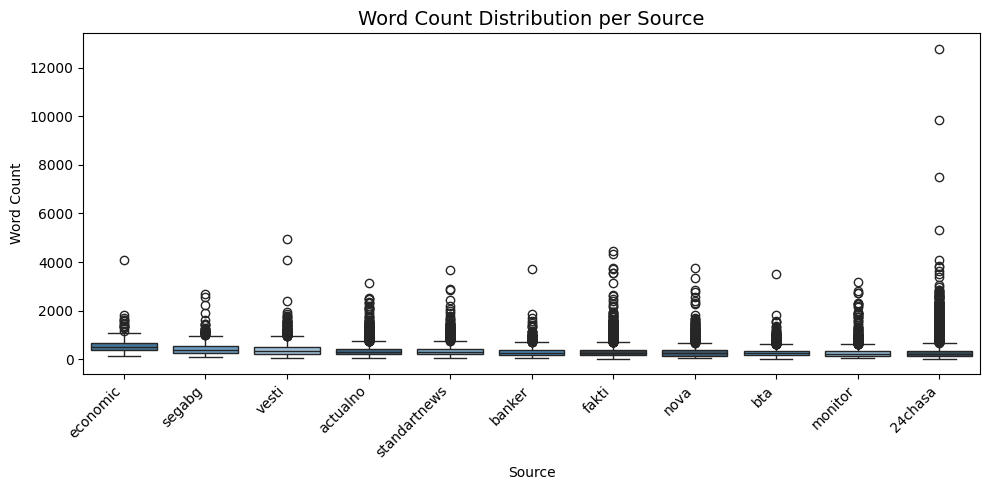

In [2005]:
fig, ax = plt.subplots(figsize=(10, 5))
sources_ordered = (
    df.groupby("source")["word_count"].median().sort_values(ascending=False).index
)
sns.boxplot(
    data=df,
    x="source",
    y="word_count",
    order=sources_ordered,
    palette="Blues_d",
    ax=ax,
    hue="source",
    legend=False,
)
ax.set_title("Word Count Distribution per Source", fontsize=14)
ax.set_xlabel("Source")
ax.set_ylabel("Word Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [2006]:
for source, threshold in [("24chasa", 3000), ("fakti", 2000)]:
    outliers = df[
        (df["source"] == source) & (df["word_count"] > threshold)
    ].sort_values("word_count", ascending=False)
    print(f"=== {source} > {threshold} words: {len(outliers)} ===")
    for _, row in outliers.head(5).iterrows():
        print(f"  [{row['word_count']} words] {row['title']}")
        print(f"  URL: {row['url']}")
        print_by_words(row["full_text"])
        print()

=== 24chasa > 3000 words: 11 ===
  [12779 words] Вижте ситуацията по пътищата на страната в момента
  URL: https://www.24chasa.bg/spravochnik/article/22866612
Информация за състоянието на републиканските пътища към 17:30 часа на 17.05.2026 г. I. МЕТЕОРОЛОГИЧНА ОБСТАНОВКА: През нощта облачността ще се
разкъсва и намалява до предимно ясно време. Ще духа до умерен вятър от запад-северозапад. Утре 18.05.2026 г.облачността ще е променлива,
след обяд - често значителна, но само на отделни места в планинските райони ще превали слабо. Ще духа умерен до
силен вятър от запад-северозапад. Максималните температури ще са между 19° и 24°, в София - около 19°. II. СЪСТОЯНИЕ НА
АВТОМАГИСТРАЛИТЕ: АМ „Тракия": Област София: Движението при Мухово от км 44+400 до км 46+480 в посока Бургас се осъществява с
повишено внимание поради обезопасяване на пътния участък в аварийната лента. Срок до 31.12.2026 г.; Област Пазарджик: Движението в участъка от
км 66+750 до км 80+050 посока Бургас се осъществява с повише

There are still outliers for words distribution, but they are valid texts, so all good 

In [2007]:
len(df)

30222

## 7. Media-type suffixes in titles and full_text

Check how many articles carry `(видео)`, `(снимка)`, `(снимки)`, `(снимка+видео)`, `(видео+снимка)` — appended by CMS editors as metadata tags, not actual article content.

In [2008]:
MEDIA_PATTERNS = ["(видео)", "(снимка)", "(снимки)", "(снимка+видео)", "(видео+снимка)", "(видео+снимки)"]

def media_re(p):
    # Allow optional spaces around + so (снимка+видео) matches (снимка + видео) too
    return re.escape(p).replace(r"\+", r"\s*\+\s*")

combined = "|".join(media_re(p) for p in MEDIA_PATTERNS)

# Per-pattern counts
for field in ["title", "full_text"]:
    print(f"--- {field} ---")
    for p in MEDIA_PATTERNS:
        n = df[field].str.contains(media_re(p), case=False, na=False, regex=True).sum()
        if n:
            print(f"  {p:<22}: {n}")
    total = df[field].str.contains(combined, case=False, na=False, regex=True).sum()
    print(f"  {'TOTAL':<22}: {total}")
    print()

--- title ---
  (видео)               : 981
  (снимка)              : 76
  (снимки)              : 316
  (видео+снимка)        : 6
  (видео+снимки)        : 49
  TOTAL                 : 1428

--- full_text ---
  (видео)               : 1185
  (снимка)              : 63
  (снимки)              : 259
  (снимка+видео)        : 2
  (видео+снимка)        : 6
  (видео+снимки)        : 80
  TOTAL                 : 1505



In [2009]:
# Per-source breakdown
for field in ["title", "full_text"]:
    mask = df[field].str.contains(combined, case=False, na=False, regex=True)
    print(f"{field} ({mask.sum()} affected):")
    print(df[mask]["source"].value_counts().to_string())
    print()

title (1428 affected):
source
actualno        709
24chasa         236
nova            195
fakti           176
monitor          80
standartnews     17
vesti            15

full_text (1505 affected):
source
actualno    1162
nova         255
monitor       44
vesti         20
fakti         16
24chasa        8



In [2010]:
def strip_media_suffixes(text: str) -> str:
    if not isinstance(text, str):
        return text
    return re.sub(combined, "", text, flags=re.IGNORECASE).strip()

In [2011]:
df["title"] = df["title"].apply(strip_media_suffixes)
df["full_text"] = df["full_text"].apply(strip_media_suffixes)

In [2012]:
mask = df["title"].str.contains(combined, case=False, na=False, regex=True)
print(f"Remaining titles with media suffixes: {mask.sum()}")

Remaining titles with media suffixes: 0


In [2013]:
mask = df["full_text"].str.contains(combined, case=False, na=False, regex=True)
print(f"Remaining fill_text with media suffixes: {mask.sum()}")

Remaining fill_text with media suffixes: 0


## 8. Remaining duplictes

In [2014]:
# Assign 3-day time windows per article
df["window"] = df["published_at_dt"].dt.tz_localize(None).dt.to_period("3D")

print(f"Articles after URL deduplication: {len(df)}")
print(
    f"Unique source+window groups (3 days): {df.groupby(['source', 'window']).ngroups}"
)

Articles after URL deduplication: 30222
Unique source+window groups (3 days): 275


In [2016]:
# Analyze how many near-duplicate pairs exist at different thresholds
# This helps pick the right threshold before removing anything

thresholds = [0.80, 0.85, 0.90, 0.95]
threshold_counts = {t: 0 for t in thresholds}
total_pairs_checked = 0

for (source, window), group in df.groupby(["source", "window"]):
    if len(group) < 2:
        continue

    texts = (group["title"] + " " + group["full_text"].fillna("")).tolist()

    try:
        vectorizer = TfidfVectorizer(min_df=1, max_features=5000)
        tfidf_matrix = vectorizer.fit_transform(texts)
        sim_matrix = cosine_similarity(tfidf_matrix)
    except ValueError:
        continue

    n = len(group)
    total_pairs_checked += n * (n - 1) // 2

    # Check upper triangle only (avoid counting pairs twice)
    for i in range(n):
        for j in range(i + 1, n):
            sim = sim_matrix[i, j]
            for t in thresholds:
                if sim >= t:
                    threshold_counts[t] += 1

print(f"Total pairs checked: {total_pairs_checked:,}")
print()
for t, count in threshold_counts.items():
    pct = count / total_pairs_checked * 100
    print(f"Threshold {t}: {count:>6} near-duplicate pairs ({pct:.2f}% of all pairs)")

Total pairs checked: 2,535,079

Threshold 0.8:    232 near-duplicate pairs (0.01% of all pairs)
Threshold 0.85:    160 near-duplicate pairs (0.01% of all pairs)
Threshold 0.9:     93 near-duplicate pairs (0.00% of all pairs)
Threshold 0.95:     12 near-duplicate pairs (0.00% of all pairs)


In [2018]:
# Inspect a few pairs above the chosen threshold to validate it makes sense
INSPECT_THRESHOLD = 0.95

print(f"Sample near-duplicate pairs at threshold >= {INSPECT_THRESHOLD}:\n")

samples_shown = 0
for (source, week), group in df.groupby(["source", "window"]):
    if len(group) < 2 or samples_shown >= 5:
        break

    texts = (group["title"] + " " + group["full_text"].fillna("")).tolist()

    try:
        vectorizer = TfidfVectorizer(min_df=1, max_features=5000)
        tfidf_matrix = vectorizer.fit_transform(texts)
        sim_matrix = cosine_similarity(tfidf_matrix)
    except ValueError:
        continue

    rows = group.reset_index(drop=True)
    n = len(rows)
    for i in range(n):
        for j in range(i + 1, n):
            if sim_matrix[i, j] >= INSPECT_THRESHOLD and samples_shown < 5:
                print(
                    f"Source: {source} | Week: {week} | Similarity: {sim_matrix[i,j]:.3f}"
                )
                print(f"  Article A: {rows.iloc[i]['title']}")
                print(f"  Article B: {rows.iloc[i]['url']}")
                print(f"  Article B: {rows.iloc[j]['title']}")
                print(f"  Article B: {rows.iloc[j]['url']}")
                print(f"  Date A: {rows.iloc[i]['published_at_dt'].date()}")
                print(f"  Date B: {rows.iloc[j]['published_at_dt'].date()}")
                print()
                samples_shown += 1

Sample near-duplicate pairs at threshold >= 0.95:

Source: 24chasa | Week: 2026-04-22 | Similarity: 0.996
  Article A: Испански прокурор поиска делото за корупция срещу съпругата на премиера да бъде прекратено
  Article B: https://www.24chasa.bg/mezhdunarodni/article/22716371
  Article B: Испански прокурор поиска делото за корупция срещу съпругата на премиера да бъде прекратено
  Article B: https://www.24chasa.bg/zdrave/article/22716371
  Date A: 2026-04-22
  Date B: 2026-04-22

Source: actualno | Week: 2026-05-08 | Similarity: 0.997
  Article A: Тръмп постави амбициозен срок за търговско споразумение с ЕС
  Article B: https://www.actualno.com/economy/trymp-postavi-ambiciozen-srok-za-tyrgovsko-sporazumenie-s-es-news_2591293.html
  Article B: ЕС си постави амбициозен срок за търговско споразумение със САЩ
  Article B: https://www.actualno.com/europe/es-si-postavi-ambiciozen-srok-za-tyrgovsko-sporazumenie-sys-sasht-news_2591293.html
  Date A: 2026-05-08
  Date B: 2026-05-08

Source: actu

In [2019]:
# Apply near-duplicate removal at chosen threshold
# Keep most recent article in each duplicate pair
CHOSEN_THRESHOLD = 0.95

rows_to_drop = set()

for (source, week), group in df.groupby(["source", "window"]):
    if len(group) < 2:
        continue

    texts = (group["title"] + " " + group["full_text"].fillna("")).tolist()

    try:
        vectorizer = TfidfVectorizer(min_df=1, max_features=5000)
        tfidf_matrix = vectorizer.fit_transform(texts)
        sim_matrix = cosine_similarity(tfidf_matrix)
    except ValueError:
        continue

    rows = group.reset_index()  # keep original index
    n = len(rows)
    for i in range(n):
        for j in range(i + 1, n):
            if sim_matrix[i, j] >= CHOSEN_THRESHOLD:
                # Drop the older article, keep the more recent one
                date_i = rows.iloc[i]["published_at_dt"]
                date_j = rows.iloc[j]["published_at_dt"]
                drop_idx = (
                    rows.iloc[i]["index"] if date_i <= date_j else rows.iloc[j]["index"]
                )
                rows_to_drop.add(drop_idx)

print(f"Near-duplicate articles to drop : {len(rows_to_drop)}")
print(f"Articles before                 : {len(df)}")

df = df.drop(index=rows_to_drop).reset_index(drop=True)
print(f"Articles after                  : {len(df)}")
print(
    f"Reduction                       : {len(rows_to_drop) / (len(df) + len(rows_to_drop)) * 100:.1f}%"
)

Near-duplicate articles to drop : 11
Articles before                 : 30222
Articles after                  : 30211
Reduction                       : 0.0%
